# Design a Machine Learning Approach to Analyse Students’ Performance Based on Their Socio-economic Status in the Kingdom of Bahrain

**MSc Artificial Intelligence — Bahrain Polytechnic**  
**Student: Jaafar Ahmed | ID: 202508989**

# Phase 9 — Open-Ended Responses and NLP Analysis

This phase analyses the two open-ended questionnaire fields preserved by Phase 2:

- `other_influencing_factors`
- `additional_suggestions`

The workflow is independent from supervised model training and does **not** open or use the sealed Phase 8 holdout. It produces an auditable bilingual corpus, response-quality analysis, word and phrase statistics, TF–IDF representations, class-specific terms, topic models, text clusters, exploratory lexical polarity, statistical association tests, visualisations, and a handoff package for Phase 10.

## Methodological safeguards

- The Phase 2 handoff manifest is the primary source of truth.
- Email addresses, URLs, phone-like strings, and long identification numbers are redacted before analytical exports.
- Empty responses and non-substantive answers such as “لا” and “لا يوجد” are reported separately and are not forced into topic models.
- Topic names are generated from their highest-weight terms and require human interpretation; the code does not pretend that automatic labels are final qualitative themes.
- Sentiment is reported only as an **exploratory lexical polarity indicator**, not as a validated psychological measure.
- Exact quotations are not exported automatically; only redacted excerpts and aggregated results are produced.
- Results created from synthetic or test data must be labelled experimental and must not be reported as final thesis findings.

## Phase 9 Folder Structure

```text
outputs/
└── Phase_09_Open_Ended_Responses_and_NLP_Analysis/
    └── Section_09_XX_Section_Title/
        └── Cell_09_XX_XX_Cell_Title/
            ├── tables/
            ├── figures/
            ├── reports/
            └── files/
```

# Section 9.1 — Configure Environment and Load the Phase 2 NLP Handoff

In [1]:
# Cell 9.1.1 — Configure Environment, Project Folders, and Analysis Settings

from pathlib import Path
from datetime import datetime
from collections import Counter, defaultdict
from itertools import combinations
import hashlib
import importlib.util
import json
import math
import os
import random
import re
import shutil
import subprocess
import sys
import unicodedata
import warnings
import zipfile

# -----------------------------------------------------------------------------
# CHANGE THESE SETTINGS ONLY
# -----------------------------------------------------------------------------
EXECUTION_ENVIRONMENT = "COLAB"  # "COLAB", "ANACONDA", or "VSCODE"
PHASE_2_MANIFEST_OVERRIDE = None
PHASE_2_NLP_DATA_OVERRIDE = None
PHASE_5_CLUSTER_DATA_OVERRIDE = None
AUTO_INSTALL_MISSING_PACKAGES = True

# NLP configuration
MIN_SUBSTANTIVE_TOKENS = 2
MAX_TFIDF_FEATURES = 6000
WORD_NGRAM_RANGE = (1, 2)
TOP_TERMS_PER_TABLE = 25
TOP_TERMS_PER_TOPIC = 10
TOPIC_K_MIN = 2
TOPIC_K_MAX = 10
TEXT_CLUSTER_K_MIN = 2
TEXT_CLUSTER_K_MAX = 10
MAX_SVD_COMPONENTS = 40
SILHOUETTE_SAMPLE_SIZE = 800
ENABLE_EXPLORATORY_LEXICAL_POLARITY = True
EXPORT_EXCEL_WORKBOOK = True
RANDOM_STATE = 42
BLAS_THREAD_LIMIT = 4  # Prevent numerical-library thread oversubscription
# -----------------------------------------------------------------------------

PROJECT_TITLE = (
    "Design a Machine Learning Approach to Analyse Students’ Performance "
    "Based on Their Socio-economic Status in the Kingdom of Bahrain"
)
PROGRAMME = "MSc Artificial Intelligence — Bahrain Polytechnic"
STUDENT_NAME = "Jaafar Ahmed"
STUDENT_ID = "202508989"

ALLOWED_ENVIRONMENTS = {"COLAB", "ANACONDA", "VSCODE"}
EXECUTION_ENVIRONMENT = EXECUTION_ENVIRONMENT.strip().upper()
if EXECUTION_ENVIRONMENT not in ALLOWED_ENVIRONMENTS:
    raise ValueError(f"EXECUTION_ENVIRONMENT must be one of {sorted(ALLOWED_ENVIRONMENTS)}")

if EXECUTION_ENVIRONMENT == "COLAB":
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        PROJECT_ROOT = Path("/content/drive/MyDrive/Jaafar_MSc_Thesis")
    except ImportError:
        print("Google Colab is unavailable; using the current directory.")
        PROJECT_ROOT = Path.cwd()
else:
    PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_ROOT = PROJECT_ROOT / "outputs"
PHASE_2_DIR = OUTPUT_ROOT / "Phase_02_Data_Cleaning_and_Feature_Preparation"
PHASE_5_DIR = OUTPUT_ROOT / "Phase_05_Unsupervised_Learning_Analysis"
PHASE_DIR = OUTPUT_ROOT / "Phase_09_Open_Ended_Responses_and_NLP_Analysis"
SHARED_DIR = PROJECT_ROOT / "shared_project_files"

for folder in [DATA_DIR, OUTPUT_ROOT, PHASE_DIR, SHARED_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

RUN_TIMESTAMP = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
random.seed(RANDOM_STATE)

# Limit low-level BLAS/OpenMP threads before NumPy and scikit-learn are imported.
# This prevents severe oversubscription while still allowing the device to work efficiently.
for variable in [
    "OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
    "VECLIB_MAXIMUM_THREADS", "NUMEXPR_NUM_THREADS",
]:
    os.environ[variable] = str(BLAS_THREAD_LIMIT)


def safe_name(text):
    text = str(text).strip().replace("—", "-").replace("–", "-")
    text = re.sub(r"[^\w\-]+", "_", text, flags=re.UNICODE)
    return re.sub(r"_+", "_", text).strip("_") or "Unnamed"


def create_cell_folders(section_number, section_title, cell_number, cell_title):
    section_folder = PHASE_DIR / safe_name(f"Section_{section_number}_{section_title}")
    cell_folder = section_folder / safe_name(f"Cell_{cell_number}_{cell_title}")
    folders = {
        "cell": cell_folder,
        "tables": cell_folder / "tables",
        "figures": cell_folder / "figures",
        "reports": cell_folder / "reports",
        "files": cell_folder / "files",
    }
    for folder in folders.values():
        folder.mkdir(parents=True, exist_ok=True)
    return folders


def save_dataframe(dataframe, folders, file_stem, save_csv=True, save_excel=True, index=False):
    paths = []
    if save_csv:
        path = folders["tables"] / f"{file_stem}.csv"
        dataframe.to_csv(path, index=index, encoding="utf-8-sig")
        paths.append(path)
    if save_excel:
        path = folders["tables"] / f"{file_stem}.xlsx"
        dataframe.to_excel(path, index=index)
        paths.append(path)
    return paths


def save_json_report(data, folders, file_stem):
    path = folders["reports"] / f"{file_stem}.json"
    with path.open("w", encoding="utf-8") as file:
        json.dump(data, file, ensure_ascii=False, indent=2, default=str)
    return path


def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def load_table(path):
    path = Path(path)
    if path.suffix.lower() == ".csv":
        try:
            return pd.read_csv(path, encoding="utf-8-sig")
        except UnicodeDecodeError:
            return pd.read_csv(path, encoding="latin-1")
    if path.suffix.lower() in {".xlsx", ".xls"}:
        return pd.read_excel(path)
    raise ValueError(f"Unsupported input format: {path.suffix}")

CELL_FOLDERS = create_cell_folders(
    "09_01", "Configure_Environment_and_Load_Handoff",
    "09_01_01", "Configure_Environment_Project_Folders_and_Settings",
)

configuration = {
    "project_title": PROJECT_TITLE,
    "programme": PROGRAMME,
    "student_name": STUDENT_NAME,
    "student_id": STUDENT_ID,
    "execution_environment": EXECUTION_ENVIRONMENT,
    "project_root": str(PROJECT_ROOT),
    "phase_2_directory": str(PHASE_2_DIR),
    "phase_5_directory": str(PHASE_5_DIR),
    "phase_9_directory": str(PHASE_DIR),
    "random_state": RANDOM_STATE,
    "run_timestamp": RUN_TIMESTAMP,
    "settings": {
        "min_substantive_tokens": MIN_SUBSTANTIVE_TOKENS,
        "max_tfidf_features": MAX_TFIDF_FEATURES,
        "word_ngram_range": WORD_NGRAM_RANGE,
        "topic_k_range": [TOPIC_K_MIN, TOPIC_K_MAX],
        "text_cluster_k_range": [TEXT_CLUSTER_K_MIN, TEXT_CLUSTER_K_MAX],
    },
}
save_json_report(configuration, CELL_FOLDERS, "09_01_01_phase_9_configuration")
print("Project root:", PROJECT_ROOT)
print("Phase 9 output directory:", PHASE_DIR)

Google Colab is unavailable; using the current directory.
Project root: C:\Users\User\Desktop\All
Phase 9 output directory: C:\Users\User\Desktop\All\outputs\Phase_09_Open_Ended_Responses_and_NLP_Analysis


In [2]:
# Cell 9.1.2 — Check Libraries and Import NLP Components

required_packages = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "scipy": "scipy",
    "sklearn": "scikit-learn",
    "joblib": "joblib",
    "openpyxl": "openpyxl",
}
optional_packages = {
    "arabic_reshaper": "arabic-reshaper",
    "bidi": "python-bidi",
}

installation_rows = []
for import_name, package_name in {**required_packages, **optional_packages}.items():
    installed = importlib.util.find_spec(import_name) is not None
    is_optional = import_name in optional_packages
    if installed:
        status = "Already installed"
    elif AUTO_INSTALL_MISSING_PACKAGES:
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
            status = "Installed during this run"
        except Exception as exc:
            if is_optional:
                status = f"Optional installation failed: {exc}"
            else:
                raise
    elif is_optional:
        status = "Optional package unavailable"
    else:
        raise ImportError(f"Missing package: {package_name}")
    installation_rows.append({"import_name": import_name, "package_name": package_name, "status": status})

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from scipy.sparse import hstack
from sklearn.cluster import KMeans
from sklearn.decomposition import NMF, TruncatedSVD
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.preprocessing import Normalizer, MinMaxScaler
from sklearn.pipeline import make_pipeline

try:
    import arabic_reshaper
    from bidi.algorithm import get_display
    ARABIC_DISPLAY_AVAILABLE = True
except Exception:
    ARABIC_DISPLAY_AVAILABLE = False

warnings.filterwarnings("default")
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 150)
pd.set_option("display.width", 220)


def display_text(text):
    text = str(text)
    if ARABIC_DISPLAY_AVAILABLE and re.search(r"[\u0600-\u06FF]", text):
        return get_display(arabic_reshaper.reshape(text))
    return text


def save_figure(figure, folders, file_stem):
    path = folders["figures"] / f"{file_stem}.png"
    figure.savefig(path, dpi=300, bbox_inches="tight")
    return path

CELL_FOLDERS = create_cell_folders(
    "09_01", "Configure_Environment_and_Load_Handoff",
    "09_01_02", "Check_Libraries_and_Import_NLP_Components",
)
installation_report = pd.DataFrame(installation_rows)
save_dataframe(installation_report, CELL_FOLDERS, "09_01_02_library_report")
display(installation_report)
print("Arabic display shaping available:", ARABIC_DISPLAY_AVAILABLE)

,import_name,package_name,status
0,pandas,pandas,Already installed
1,numpy,numpy,Already installed
2,matplotlib,matplotlib,Already installed
3,scipy,scipy,Already installed
4,sklearn,scikit-learn,Already installed
5,joblib,joblib,Already installed
6,openpyxl,openpyxl,Already installed
7,arabic_reshaper,arabic-reshaper,Installed during this run
8,bidi,python-bidi,Installed during this run


Arabic display shaping available: True


In [3]:
# Cell 9.1.3 — Locate the Phase 2 NLP Manifest and Load the Corpus Dataset

def locate_phase_2_nlp_manifest():
    candidates = []
    if PHASE_2_MANIFEST_OVERRIDE is not None:
        candidates.append(Path(PHASE_2_MANIFEST_OVERRIDE).expanduser())
    candidates.extend([
        PHASE_2_DIR / "phase_02_handoff_manifest_for_phase_09.json",
        OUTPUT_ROOT / "phase_02_handoff_manifest_for_phase_09.json",
        PROJECT_ROOT / "phase_02_handoff_manifest_for_phase_09.json",
        Path.cwd() / "phase_02_handoff_manifest_for_phase_09.json",
    ])
    if PHASE_2_DIR.exists():
        candidates.extend(PHASE_2_DIR.rglob("phase_02_handoff_manifest_for_phase_09.json"))
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return None


def resolve_phase_2_nlp_dataset(manifest):
    if PHASE_2_NLP_DATA_OVERRIDE is not None:
        path = Path(PHASE_2_NLP_DATA_OVERRIDE).expanduser()
        if path.exists():
            return path
        raise FileNotFoundError(f"PHASE_2_NLP_DATA_OVERRIDE not found: {path}")

    recorded = manifest.get("primary_input_for_phase_9")
    if recorded and Path(recorded).exists():
        return Path(recorded)

    candidates = [
        DATA_DIR / "phase_02_open_ended_dataset_for_phase_09.csv",
        DATA_DIR / "phase_02_open_ended_dataset_for_phase_09.xlsx",
        PROJECT_ROOT / "phase_02_open_ended_dataset_for_phase_09.csv",
        Path.cwd() / "data" / "phase_02_open_ended_dataset_for_phase_09.csv",
        Path.cwd() / "phase_02_open_ended_dataset_for_phase_09.csv",
    ]
    if PHASE_2_DIR.exists():
        candidates.extend(PHASE_2_DIR.rglob("phase_02_open_ended_dataset_for_phase_09.csv"))
        candidates.extend(PHASE_2_DIR.rglob("phase_02_open_ended_dataset_for_phase_09.xlsx"))
    for candidate in candidates:
        if Path(candidate).exists():
            return Path(candidate)
    raise FileNotFoundError(
        "Phase 2 NLP dataset not found. Run Phase 2 first or set PHASE_2_NLP_DATA_OVERRIDE."
    )

PHASE_2_MANIFEST_PATH = locate_phase_2_nlp_manifest()
if PHASE_2_MANIFEST_PATH is not None:
    with PHASE_2_MANIFEST_PATH.open("r", encoding="utf-8") as file:
        phase_2_manifest = json.load(file)
else:
    phase_2_manifest = {}

PHASE_2_NLP_DATA_PATH = resolve_phase_2_nlp_dataset(phase_2_manifest)
nlp_wide = load_table(PHASE_2_NLP_DATA_PATH)
if nlp_wide.empty:
    raise ValueError("The Phase 2 NLP dataset is empty.")

INPUT_SHA256 = sha256_file(PHASE_2_NLP_DATA_PATH)
RECORDED_SHA256 = phase_2_manifest.get("phase_9_input_sha256")
HASH_MATCH = RECORDED_SHA256 is None or INPUT_SHA256 == RECORDED_SHA256

IDENTIFIER_COLUMN = phase_2_manifest.get("identifier_column", "student_record_id")
GROUP_COLUMN = phase_2_manifest.get("group_column", "family_id")
TARGET_COLUMN = phase_2_manifest.get("target_column", "academic_performance_class")
TEXT_COLUMNS = phase_2_manifest.get(
    "open_text_columns",
    ["other_influencing_factors", "additional_suggestions"],
)

required_columns = [IDENTIFIER_COLUMN, GROUP_COLUMN, TARGET_COLUMN, *TEXT_COLUMNS]
missing_columns = [column for column in required_columns if column not in nlp_wide.columns]
if missing_columns:
    raise KeyError(f"Missing required Phase 9 columns: {missing_columns}")
if not HASH_MATCH:
    raise AssertionError("Phase 2 NLP dataset hash does not match the Phase 2 handoff manifest.")

CELL_FOLDERS = create_cell_folders(
    "09_01", "Configure_Environment_and_Load_Handoff",
    "09_01_03", "Locate_Phase_2_NLP_Manifest_and_Load_Dataset",
)
loading_summary = {
    "manifest_path": str(PHASE_2_MANIFEST_PATH) if PHASE_2_MANIFEST_PATH else None,
    "dataset_path": str(PHASE_2_NLP_DATA_PATH),
    "dataset_sha256": INPUT_SHA256,
    "recorded_sha256": RECORDED_SHA256,
    "hash_match": HASH_MATCH,
    "rows": int(nlp_wide.shape[0]),
    "columns": int(nlp_wide.shape[1]),
    "identifier_column": IDENTIFIER_COLUMN,
    "group_column": GROUP_COLUMN,
    "target_column": TARGET_COLUMN,
    "text_columns": TEXT_COLUMNS,
    "holdout_loaded": False,
}
save_json_report(loading_summary, CELL_FOLDERS, "09_01_03_loading_summary")
print("Phase 2 manifest:", PHASE_2_MANIFEST_PATH)
print("Phase 2 NLP dataset:", PHASE_2_NLP_DATA_PATH)
print("Input SHA-256 verified:", HASH_MATCH)
print("Dataset shape:", nlp_wide.shape)
display(nlp_wide.head())

Phase 2 manifest: C:\Users\User\Desktop\All\outputs\Phase_02_Data_Cleaning_and_Feature_Preparation\phase_02_handoff_manifest_for_phase_09.json
Phase 2 NLP dataset: C:\Users\User\Desktop\All\data\phase_02_open_ended_dataset_for_phase_09.csv
Input SHA-256 verified: True
Dataset shape: (2500, 6)


,student_record_id,family_id,academic_performance_class,other_influencing_factors,additional_suggestions,response_language
0,STU000001,1,High,قلة النوم وتنظيم الوقت,NaN,Arabic
1,STU000002,1,High,الأصدقاء والبيئة الاجتماعية,NaN,Arabic
2,STU000003,1,High,توفير مكان هادئ ومناسب للدراسة,تقديم برامج دعم للطلبة ذوي التحصيل المنخفض,Arabic
3,STU000004,2,High,الاستخدام المفرط للألعاب الإلكترونية,تعزيز التواصل بين المدرسة وأولياء الأمور,Arabic
4,STU000005,2,Low,الاستخدام المفرط للألعاب الإلكترونية,توفير حصص تقوية بأسعار مناسبة,Arabic


# Section 9.2 — Schema, Privacy, and Response-Quality Audit

In [4]:
# Cell 9.2.1 — Define Text Normalisation, PII Redaction, and Response-Status Rules

ARABIC_DIACRITICS = re.compile(r"[\u0617-\u061A\u064B-\u0652\u0670\u06D6-\u06ED]")
ARABIC_TATWEEL = "\u0640"

NON_SUBSTANTIVE_PATTERNS = {
    "", "لا", "لا يوجد", "لايوجد", "لا توجد", "لا شيء", "لاشيء",
    "مافي", "ما في", "ليس لدي", "بدون", "none", "no", "nothing",
    "n/a", "na", "nil", "not applicable", "no comment", "no comments",
    "لا تعليق", "لا اقتراح", "لا اقتراحات",
}

ARABIC_STOPWORDS = {
    "في", "من", "على", "إلى", "الى", "عن", "مع", "هذا", "هذه", "ذلك", "تلك",
    "هو", "هي", "هم", "هن", "كان", "كانت", "يكون", "تكون", "و", "أو", "او",
    "ثم", "كما", "لكن", "لأن", "لان", "أن", "ان", "إن", "اذا", "إذا", "ما",
    "كل", "أي", "اي", "قد", "تم", "هناك", "هنا", "عند", "بعد", "قبل", "بين",
    "خلال", "بشكل", "بسبب", "بعض", "أكثر", "اكثر", "أقل", "اقل", "جدا", "جداً",
    "التي", "الذي", "الذين", "اللتي", "لدى", "لدي", "لهم", "لها", "له", "حتى",
    "عدم", "غير", "نحو", "ضمن", "عبر", "أمام", "امام", "حول", "مثل", "مثلًا",
}
ENGLISH_STOPWORDS = {
    "the", "a", "an", "and", "or", "but", "if", "then", "than", "to", "of", "in",
    "on", "for", "from", "with", "without", "by", "at", "as", "is", "are", "was",
    "were", "be", "been", "being", "this", "that", "these", "those", "it", "its",
    "they", "their", "we", "our", "you", "your", "he", "she", "his", "her", "can",
    "could", "should", "would", "may", "might", "must", "very", "more", "most", "less",
    "not", "no", "none", "there", "here", "have", "has", "had", "do", "does", "did",
}
STOPWORDS = ARABIC_STOPWORDS | ENGLISH_STOPWORDS


def redact_pii(text):
    if pd.isna(text):
        return "", []
    text = str(text)
    flags = []
    patterns = [
        (r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b", "<EMAIL>", "email"),
        (r"https?://\S+|www\.\S+", "<URL>", "url"),
        (r"(?<!\d)(?:\+?973[-\s]?)?[367]\d{7}(?!\d)", "<PHONE>", "phone"),
        (r"(?<!\d)\d{9,12}(?!\d)", "<LONG_NUMBER>", "long_number"),
    ]
    for pattern, replacement, label in patterns:
        if re.search(pattern, text, flags=re.IGNORECASE):
            flags.append(label)
            text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)
    return text, sorted(set(flags))


def normalize_arabic(text):
    text = ARABIC_DIACRITICS.sub("", text)
    text = text.replace(ARABIC_TATWEEL, "")
    translation = str.maketrans({
        "أ": "ا", "إ": "ا", "آ": "ا", "ٱ": "ا",
        "ى": "ي", "ؤ": "و", "ئ": "ي", "ة": "ه",
    })
    return text.translate(translation)


def normalize_text(text):
    redacted, pii_flags = redact_pii(text)
    text = unicodedata.normalize("NFKC", redacted).strip().lower()
    text = normalize_arabic(text)
    text = re.sub(r"<\s*(email|url|phone|long_number)\s*>", r" pii_\1 ", text)
    text = re.sub(r"[^\w\s\u0600-\u06FF]", " ", text, flags=re.UNICODE)
    text = re.sub(r"_+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text, pii_flags


def tokenize(text, remove_stopwords=True):
    tokens = re.findall(r"[A-Za-z\u0600-\u06FF][A-Za-z\u0600-\u06FF0-9]*", str(text))
    if remove_stopwords:
        tokens = [token for token in tokens if token not in STOPWORDS and len(token) > 1]
    return tokens


def detect_script(text):
    text = str(text)
    arabic_count = len(re.findall(r"[\u0600-\u06FF]", text))
    latin_count = len(re.findall(r"[A-Za-z]", text))
    total = arabic_count + latin_count
    if total == 0:
        return "Unknown"
    arabic_ratio = arabic_count / total
    if arabic_ratio >= 0.80:
        return "Arabic"
    if arabic_ratio <= 0.20:
        return "English"
    return "Mixed"


def classify_response_status(raw_text, normalized_text, tokens):
    if pd.isna(raw_text) or not str(raw_text).strip():
        return "Missing"
    if normalized_text in NON_SUBSTANTIVE_PATTERNS:
        return "Non-substantive"
    if len(tokens) < MIN_SUBSTANTIVE_TOKENS:
        return "Too short"
    return "Substantive"

print("Text-processing rules configured.")

Text-processing rules configured.


In [5]:
# Cell 9.2.2 — Convert the Wide Dataset to an Auditable Long-Format Corpus

question_labels = {
    "other_influencing_factors": "Other influencing factors",
    "additional_suggestions": "Additional suggestions",
}

long_rows = []
for _, row in nlp_wide.iterrows():
    for text_column in TEXT_COLUMNS:
        raw_value = row[text_column]
        redacted_text, pii_flags = redact_pii(raw_value)
        normalized_text, _ = normalize_text(raw_value)
        all_tokens = tokenize(normalized_text, remove_stopwords=False)
        analysis_tokens = tokenize(normalized_text, remove_stopwords=True)
        status = classify_response_status(raw_value, normalized_text, analysis_tokens)
        long_rows.append({
            "response_id": f"{row[IDENTIFIER_COLUMN]}__{text_column}",
            IDENTIFIER_COLUMN: row[IDENTIFIER_COLUMN],
            GROUP_COLUMN: row[GROUP_COLUMN],
            TARGET_COLUMN: row[TARGET_COLUMN],
            "question_column": text_column,
            "question_label": question_labels.get(text_column, text_column),
            "response_language_recorded": row.get("response_language", pd.NA),
            "response_language_detected": detect_script(redacted_text),
            "response_status": status,
            "pii_flag": bool(pii_flags),
            "pii_types": ", ".join(pii_flags),
            "redacted_excerpt": redacted_text[:240] if redacted_text else "",
            "normalized_text": normalized_text,
            "character_count": len(normalized_text),
            "token_count_all": len(all_tokens),
            "token_count_analysis": len(analysis_tokens),
            "unique_token_count": len(set(analysis_tokens)),
            "analysis_text": " ".join(analysis_tokens),
        })

responses_long = pd.DataFrame(long_rows)
substantive_responses = responses_long.loc[
    responses_long["response_status"].eq("Substantive")
].copy()
substantive_responses["normalized_duplicate_frequency"] = (
    substantive_responses.groupby(["question_column", "normalized_text"])["response_id"]
    .transform("size")
)
substantive_responses["is_normalized_duplicate"] = (
    substantive_responses["normalized_duplicate_frequency"] > 1
)

CELL_FOLDERS = create_cell_folders(
    "09_02", "Schema_Privacy_and_Response_Quality_Audit",
    "09_02_02", "Create_Auditable_Long_Format_Corpus",
)
save_dataframe(responses_long, CELL_FOLDERS, "09_02_02_all_responses_long")
save_dataframe(substantive_responses, CELL_FOLDERS, "09_02_02_substantive_responses")
print("All response rows:", len(responses_long))
print("Substantive response rows:", len(substantive_responses))
display(responses_long.head(10))

All response rows: 5000
Substantive response rows: 3057


,response_id,student_record_id,family_id,academic_performance_class,question_column,question_label,response_language_recorded,response_language_detected,response_status,pii_flag,pii_types,redacted_excerpt,normalized_text,character_count,token_count_all,token_count_analysis,unique_token_count,analysis_text
0,STU000001__other_influencing_factors,STU000001,1,High,other_influencing_factors,Other influencing factors,Arabic,Arabic,Substantive,False,,قلة النوم وتنظيم الوقت,قله النوم وتنظيم الوقت,22,4,4,4,قله النوم وتنظيم الوقت
1,STU000001__additional_suggestions,STU000001,1,High,additional_suggestions,Additional suggestions,Arabic,Unknown,Missing,False,,,,0,0,0,0,
2,STU000002__other_influencing_factors,STU000002,1,High,other_influencing_factors,Other influencing factors,Arabic,Arabic,Substantive,False,,الأصدقاء والبيئة الاجتماعية,الاصدقاء والبييه الاجتماعيه,27,3,3,3,الاصدقاء والبييه الاجتماعيه
3,STU000002__additional_suggestions,STU000002,1,High,additional_suggestions,Additional suggestions,Arabic,Unknown,Missing,False,,,,0,0,0,0,
4,STU000003__other_influencing_factors,STU000003,1,High,other_influencing_factors,Other influencing factors,Arabic,Arabic,Substantive,False,,توفير مكان هادئ ومناسب للدراسة,توفير مكان هادي ومناسب للدراسه,30,5,5,5,توفير مكان هادي ومناسب للدراسه
5,STU000003__additional_suggestions,STU000003,1,High,additional_suggestions,Additional suggestions,Arabic,Arabic,Substantive,False,,تقديم برامج دعم للطلبة ذوي التحصيل المنخفض,تقديم برامج دعم للطلبه ذوي التحصيل المنخفض,42,7,7,7,تقديم برامج دعم للطلبه ذوي التحصيل المنخفض
6,STU000004__other_influencing_factors,STU000004,2,High,other_influencing_factors,Other influencing factors,Arabic,Arabic,Substantive,False,,الاستخدام المفرط للألعاب الإلكترونية,الاستخدام المفرط للالعاب الالكترونيه,36,4,4,4,الاستخدام المفرط للالعاب الالكترونيه
7,STU000004__additional_suggestions,STU000004,2,High,additional_suggestions,Additional suggestions,Arabic,Arabic,Substantive,False,,تعزيز التواصل بين المدرسة وأولياء الأمور,تعزيز التواصل بين المدرسه واولياء الامور,40,6,5,5,تعزيز التواصل المدرسه واولياء الامور
8,STU000005__other_influencing_factors,STU000005,2,Low,other_influencing_factors,Other influencing factors,Arabic,Arabic,Substantive,False,,الاستخدام المفرط للألعاب الإلكترونية,الاستخدام المفرط للالعاب الالكترونيه,36,4,4,4,الاستخدام المفرط للالعاب الالكترونيه
9,STU000005__additional_suggestions,STU000005,2,Low,additional_suggestions,Additional suggestions,Arabic,Arabic,Substantive,False,,توفير حصص تقوية بأسعار مناسبة,توفير حصص تقويه باسعار مناسبه,29,5,5,5,توفير حصص تقويه باسعار مناسبه


In [6]:
# Cell 9.2.3 — Audit Coverage, Duplication, Language, and Possible PII

coverage = (
    responses_long.groupby(["question_column", "question_label", "response_status"])
    .size().rename("response_count").reset_index()
)
coverage["percentage_within_question"] = (
    coverage["response_count"] /
    coverage.groupby("question_column")["response_count"].transform("sum") * 100
)

question_quality = (
    responses_long.groupby(["question_column", "question_label"])
    .agg(
        total_records=("response_id", "size"),
        substantive_responses=("response_status", lambda s: int((s == "Substantive").sum())),
        missing_responses=("response_status", lambda s: int((s == "Missing").sum())),
        non_substantive_responses=("response_status", lambda s: int((s == "Non-substantive").sum())),
        too_short_responses=("response_status", lambda s: int((s == "Too short").sum())),
        possible_pii_responses=("pii_flag", "sum"),
        median_character_count=("character_count", "median"),
        median_analysis_tokens=("token_count_analysis", "median"),
    ).reset_index()
)
question_quality["substantive_response_rate"] = (
    question_quality["substantive_responses"] / question_quality["total_records"]
)

duplication_audit = (
    substantive_responses.groupby(["question_column", "normalized_text"])
    .agg(
        frequency=("response_id", "size"),
        target_class_count=(TARGET_COLUMN, "nunique"),
        redacted_excerpt=("redacted_excerpt", "first"),
    ).reset_index().sort_values(["question_column", "frequency"], ascending=[True, False])
)

duplication_summary = (
    substantive_responses.groupby("question_column")
    .agg(
        substantive_responses=("response_id", "size"),
        unique_normalized_responses=("normalized_text", "nunique"),
        duplicated_response_rows=("is_normalized_duplicate", "sum"),
    ).reset_index()
)
duplication_summary["unique_response_ratio"] = (
    duplication_summary["unique_normalized_responses"] /
    duplication_summary["substantive_responses"].replace(0, np.nan)
)
duplication_summary["duplicated_row_ratio"] = (
    duplication_summary["duplicated_response_rows"] /
    duplication_summary["substantive_responses"].replace(0, np.nan)
)

language_summary = (
    responses_long.groupby(["question_column", "response_language_detected"])
    .size().rename("response_count").reset_index()
)
pii_audit = responses_long.loc[
    responses_long["pii_flag"],
    ["response_id", IDENTIFIER_COLUMN, "question_column", "pii_types", "redacted_excerpt"],
].copy()

CELL_FOLDERS = create_cell_folders(
    "09_02", "Schema_Privacy_and_Response_Quality_Audit",
    "09_02_03", "Audit_Coverage_Duplication_Language_and_PII",
)
for name, frame in {
    "09_02_03_response_coverage": coverage,
    "09_02_03_question_quality": question_quality,
    "09_02_03_duplication_audit": duplication_audit,
    "09_02_03_duplication_summary": duplication_summary,
    "09_02_03_language_summary": language_summary,
    "09_02_03_possible_pii_audit": pii_audit,
}.items():
    save_dataframe(frame, CELL_FOLDERS, name)

display(question_quality)
display(duplication_summary)
print("Responses with automatically detected PII patterns:", len(pii_audit))

,question_column,question_label,total_records,substantive_responses,missing_responses,non_substantive_responses,too_short_responses,possible_pii_responses,median_character_count,median_analysis_tokens,substantive_response_rate
0,additional_suggestions,Additional suggestions,2500,1397,731,372,0,0,29.0,4.0,0.5588
1,other_influencing_factors,Other influencing factors,2500,1660,543,297,0,0,27.0,4.0,0.6640


,question_column,substantive_responses,unique_normalized_responses,duplicated_response_rows,unique_response_ratio,duplicated_row_ratio
0,additional_suggestions,1397,8,1397,0.005727,1.0
1,other_influencing_factors,1660,10,1660,0.006024,1.0


Responses with automatically detected PII patterns: 0


# Section 9.3 — Descriptive Response Analysis

In [7]:
# Cell 9.3.1 — Analyse Response Rates and Length by Academic Class

response_rate_by_class = (
    responses_long.assign(is_substantive=responses_long["response_status"].eq("Substantive"))
    .groupby(["question_column", TARGET_COLUMN])
    .agg(
        records=("response_id", "size"),
        substantive_responses=("is_substantive", "sum"),
        median_character_count=("character_count", "median"),
        median_token_count=("token_count_analysis", "median"),
    ).reset_index()
)
response_rate_by_class["substantive_response_rate"] = (
    response_rate_by_class["substantive_responses"] / response_rate_by_class["records"]
)

length_summary = (
    substantive_responses.groupby(["question_column", TARGET_COLUMN])
    .agg(
        response_count=("response_id", "size"),
        mean_characters=("character_count", "mean"),
        median_characters=("character_count", "median"),
        std_characters=("character_count", "std"),
        mean_tokens=("token_count_analysis", "mean"),
        median_tokens=("token_count_analysis", "median"),
        lexical_diversity=("analysis_text", lambda s: (
            len(set(" ".join(s).split())) / max(1, len(" ".join(s).split()))
        )),
    ).reset_index()
)

CELL_FOLDERS = create_cell_folders(
    "09_03", "Descriptive_Response_Analysis",
    "09_03_01", "Analyse_Response_Rates_and_Length_by_Class",
)
save_dataframe(response_rate_by_class, CELL_FOLDERS, "09_03_01_response_rate_by_class")
save_dataframe(length_summary, CELL_FOLDERS, "09_03_01_length_summary_by_class")
display(response_rate_by_class)
display(length_summary)

,question_column,academic_performance_class,records,substantive_responses,median_character_count,median_token_count,substantive_response_rate
0,additional_suggestions,High,625,368,29.0,5.0,0.5888
1,additional_suggestions,Low,625,345,29.0,4.0,0.5520
2,additional_suggestions,Medium,1250,684,29.0,4.0,0.5472
3,other_influencing_factors,High,625,400,26.0,4.0,0.6400
4,other_influencing_factors,Low,625,427,27.0,4.0,0.6832
5,other_influencing_factors,Medium,1250,833,27.0,4.0,0.6664


,question_column,academic_performance_class,response_count,mean_characters,median_characters,std_characters,mean_tokens,median_tokens,lexical_diversity
0,additional_suggestions,High,368,37.434783,40.0,6.360735,5.437500,5.0,0.019490
1,additional_suggestions,Low,345,37.191304,40.0,6.398440,5.347826,5.0,0.021138
2,additional_suggestions,Medium,684,37.162281,40.0,6.626734,5.418129,5.0,0.010523
3,other_influencing_factors,High,400,30.697500,31.0,5.008363,4.237500,4.0,0.024779
4,other_influencing_factors,Low,427,30.957845,31.0,4.854513,4.210773,4.0,0.023359
5,other_influencing_factors,Medium,833,30.809124,31.0,4.699459,4.205282,4.0,0.011990


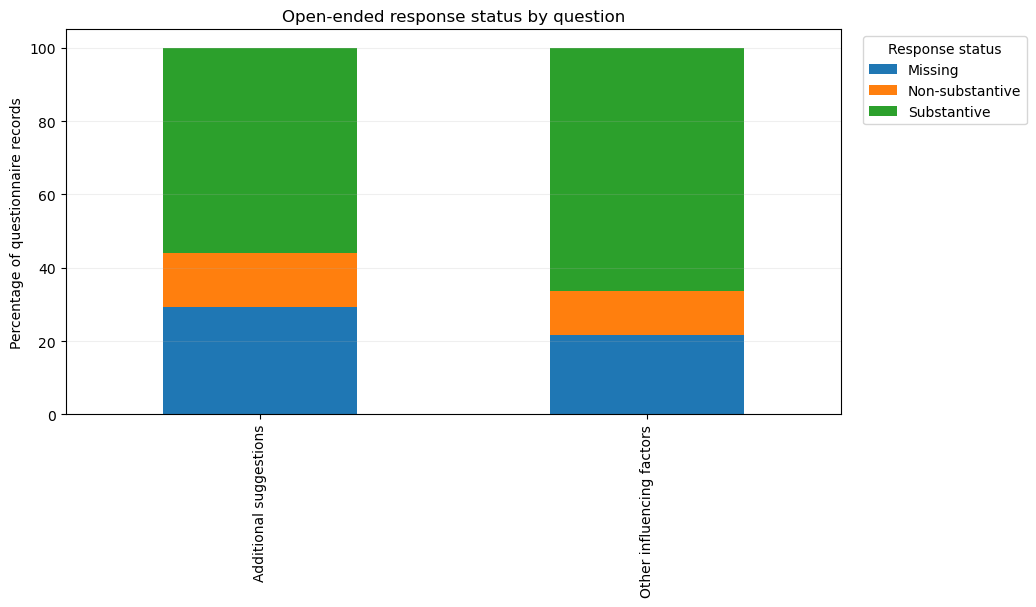

C:\Users\User\AppData\Local\Temp\ipykernel_8236\2764615344.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot(values, labels=classes, showfliers=False)


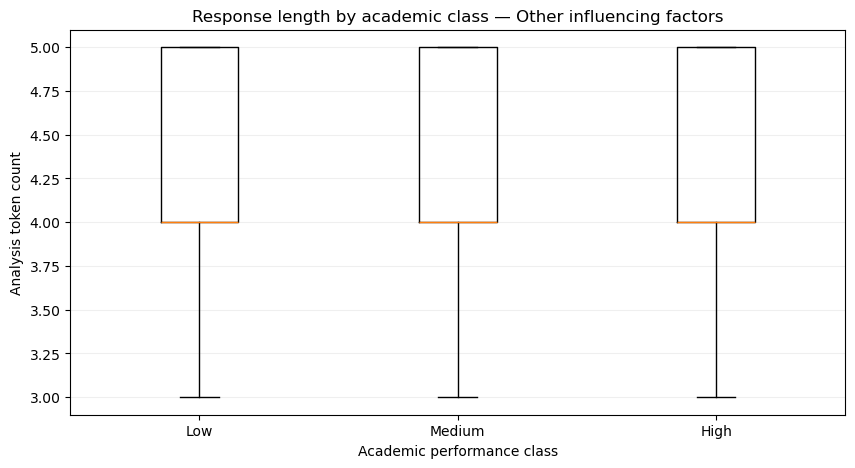

C:\Users\User\AppData\Local\Temp\ipykernel_8236\2764615344.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot(values, labels=classes, showfliers=False)


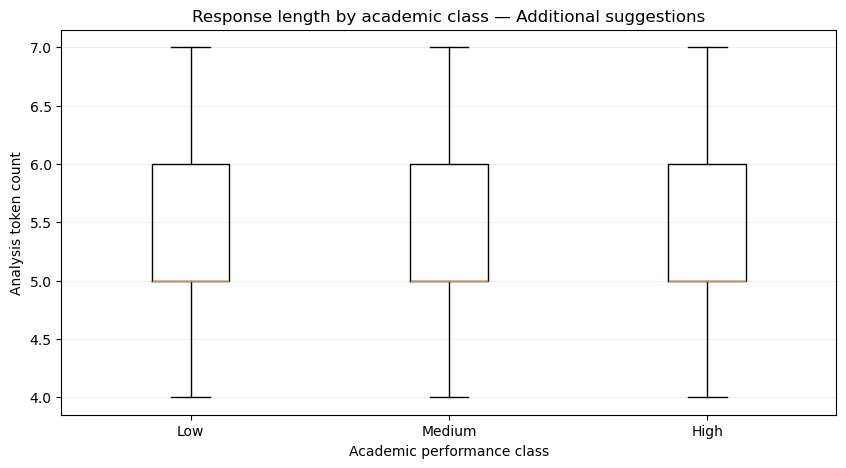

[WindowsPath('C:/Users/User/Desktop/All/outputs/Phase_09_Open_Ended_Responses_and_NLP_Analysis/Section_09_03_Descriptive_Response_Analysis/Cell_09_03_02_Create_Coverage_and_Length_Visualisations/tables/09_03_02_visualisation_catalogue.csv'),
 WindowsPath('C:/Users/User/Desktop/All/outputs/Phase_09_Open_Ended_Responses_and_NLP_Analysis/Section_09_03_Descriptive_Response_Analysis/Cell_09_03_02_Create_Coverage_and_Length_Visualisations/tables/09_03_02_visualisation_catalogue.xlsx')]

In [8]:
# Cell 9.3.2 — Create Response Coverage and Length Visualisations

CELL_FOLDERS = create_cell_folders(
    "09_03", "Descriptive_Response_Analysis",
    "09_03_02", "Create_Coverage_and_Length_Visualisations",
)
visualisation_rows = []

plot_data = coverage.pivot(index="question_label", columns="response_status", values="percentage_within_question").fillna(0)
figure, axis = plt.subplots(figsize=(10, 5))
plot_data.plot(kind="bar", stacked=True, ax=axis)
axis.set_title("Open-ended response status by question")
axis.set_xlabel("")
axis.set_ylabel("Percentage of questionnaire records")
axis.legend(title="Response status", bbox_to_anchor=(1.02, 1), loc="upper left")
axis.grid(axis="y", alpha=0.2)
path = save_figure(figure, CELL_FOLDERS, "09_03_02_response_status_by_question")
plt.show()
plt.close(figure)
visualisation_rows.append({"figure_name": "Response status by question", "path": str(path)})

for question in TEXT_COLUMNS:
    subset = substantive_responses.loc[substantive_responses["question_column"].eq(question)]
    if subset.empty:
        continue
    figure, axis = plt.subplots(figsize=(10, 5))
    classes = [c for c in ["Low", "Medium", "High"] if c in subset[TARGET_COLUMN].unique()]
    values = [subset.loc[subset[TARGET_COLUMN].eq(c), "token_count_analysis"].to_numpy() for c in classes]
    axis.boxplot(values, labels=classes, showfliers=False)
    axis.set_title(f"Response length by academic class — {question_labels.get(question, question)}")
    axis.set_xlabel("Academic performance class")
    axis.set_ylabel("Analysis token count")
    axis.grid(axis="y", alpha=0.2)
    path = save_figure(figure, CELL_FOLDERS, f"09_03_02_length_by_class_{safe_name(question)}")
    plt.show()
    plt.close(figure)
    visualisation_rows.append({"figure_name": f"Length by class — {question}", "path": str(path)})

visualisation_catalogue_early = pd.DataFrame(visualisation_rows)
save_dataframe(visualisation_catalogue_early, CELL_FOLDERS, "09_03_02_visualisation_catalogue")

# Section 9.4 — Word, Phrase, and TF–IDF Analysis

In [9]:
# Cell 9.4.1 — Calculate Top Unigrams and Bigrams

def ngram_frequency_table(texts, ngram_range, top_n=25):
    texts = [text for text in texts if isinstance(text, str) and text.strip()]
    if not texts:
        return pd.DataFrame(columns=["term", "frequency"])
    min_df = 1 if len(texts) < 50 else 2
    vectorizer = CountVectorizer(
        analyzer="word",
        token_pattern=r"(?u)\b[^\W\d_][^\W_]+\b",
        ngram_range=ngram_range,
        min_df=min_df,
        max_df=1.0,
    )
    matrix = vectorizer.fit_transform(texts)
    frequencies = np.asarray(matrix.sum(axis=0)).ravel()
    terms = vectorizer.get_feature_names_out()
    table = pd.DataFrame({"term": terms, "frequency": frequencies})
    return table.sort_values(["frequency", "term"], ascending=[False, True]).head(top_n).reset_index(drop=True)

frequency_tables = []
for question in ["ALL", *TEXT_COLUMNS]:
    subset = substantive_responses if question == "ALL" else substantive_responses.loc[
        substantive_responses["question_column"].eq(question)
    ]
    for ngram_name, ngram_range in [("unigram", (1, 1)), ("bigram", (2, 2))]:
        table = ngram_frequency_table(subset["analysis_text"], ngram_range, TOP_TERMS_PER_TABLE)
        table.insert(0, "question_column", question)
        table.insert(1, "ngram_type", ngram_name)
        frequency_tables.append(table)

term_frequencies = pd.concat(frequency_tables, ignore_index=True) if frequency_tables else pd.DataFrame()

CELL_FOLDERS = create_cell_folders(
    "09_04", "Word_Phrase_and_TFIDF_Analysis",
    "09_04_01", "Calculate_Top_Unigrams_and_Bigrams",
)
save_dataframe(term_frequencies, CELL_FOLDERS, "09_04_01_top_unigrams_and_bigrams")
display(term_frequencies.head(30))

,question_column,ngram_type,term,frequency
0,ALL,unigram,المدرسه,361
1,ALL,unigram,داخل,354
2,ALL,unigram,توفير,336
3,ALL,unigram,تقديم,334
4,ALL,unigram,دعم,334
5,ALL,unigram,للطلبه,334
6,ALL,unigram,التعليميه,324
7,ALL,unigram,التعلم,203
8,ALL,unigram,الفرديه,203
9,ALL,unigram,الفروق,203


In [10]:
# Cell 9.4.2 — Fit the Word and Character TF–IDF Representations

corpus_text = substantive_responses["analysis_text"].fillna("").tolist()
if len(corpus_text) < 10:
    raise ValueError("Too few substantive responses for TF–IDF analysis.")

min_df = 1 if len(corpus_text) < 50 else 2
word_tfidf_vectorizer = TfidfVectorizer(
    analyzer="word",
    token_pattern=r"(?u)\b[^\W\d_][^\W_]+\b",
    ngram_range=WORD_NGRAM_RANGE,
    min_df=min_df,
    max_df=0.98,
    max_features=MAX_TFIDF_FEATURES,
    sublinear_tf=True,
    norm="l2",
)
char_tfidf_vectorizer = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=min_df,
    max_features=max(1500, MAX_TFIDF_FEATURES // 2),
    sublinear_tf=True,
    norm="l2",
)

X_word_tfidf = word_tfidf_vectorizer.fit_transform(corpus_text)
X_char_tfidf = char_tfidf_vectorizer.fit_transform(corpus_text)
WORD_FEATURE_NAMES = word_tfidf_vectorizer.get_feature_names_out()
CHAR_FEATURE_NAMES = char_tfidf_vectorizer.get_feature_names_out()

representation_summary = pd.DataFrame([
    {
        "representation": "Word TF-IDF",
        "rows": X_word_tfidf.shape[0],
        "features": X_word_tfidf.shape[1],
        "density": X_word_tfidf.nnz / (X_word_tfidf.shape[0] * X_word_tfidf.shape[1]),
        "ngram_range": str(WORD_NGRAM_RANGE),
    },
    {
        "representation": "Character TF-IDF",
        "rows": X_char_tfidf.shape[0],
        "features": X_char_tfidf.shape[1],
        "density": X_char_tfidf.nnz / (X_char_tfidf.shape[0] * X_char_tfidf.shape[1]),
        "ngram_range": "(3, 5)",
    },
])

CELL_FOLDERS = create_cell_folders(
    "09_04", "Word_Phrase_and_TFIDF_Analysis",
    "09_04_02", "Fit_Word_and_Character_TFIDF_Representations",
)
save_dataframe(representation_summary, CELL_FOLDERS, "09_04_02_tfidf_representation_summary")
joblib.dump(word_tfidf_vectorizer, CELL_FOLDERS["files"] / "09_04_02_word_tfidf_vectorizer.joblib")
joblib.dump(char_tfidf_vectorizer, CELL_FOLDERS["files"] / "09_04_02_character_tfidf_vectorizer.joblib")
display(representation_summary)

,representation,rows,features,density,ngram_range
0,Word TF-IDF,3057,145,0.058744,"(1, 2)"
1,Character TF-IDF,3057,977,0.072594,"(3, 5)"


In [11]:
# Cell 9.4.3 — Identify Terms Most Associated with Each Academic Class

def class_specific_tfidf_terms(X, feature_names, labels, top_n=25):
    rows = []
    labels = pd.Series(labels).reset_index(drop=True)
    for class_name in sorted(labels.dropna().unique()):
        class_mask = labels.eq(class_name).to_numpy()
        other_mask = ~class_mask
        class_mean = np.asarray(X[class_mask].mean(axis=0)).ravel()
        other_mean = np.asarray(X[other_mask].mean(axis=0)).ravel() if other_mask.any() else np.zeros_like(class_mean)
        difference = class_mean - other_mean
        ranking = np.argsort(difference)[::-1][:top_n]
        for rank, index in enumerate(ranking, start=1):
            rows.append({
                "academic_class": class_name,
                "rank": rank,
                "term": feature_names[index],
                "class_mean_tfidf": class_mean[index],
                "other_classes_mean_tfidf": other_mean[index],
                "tfidf_difference": difference[index],
            })
    return pd.DataFrame(rows)

class_specific_terms_all = class_specific_tfidf_terms(
    X_word_tfidf,
    WORD_FEATURE_NAMES,
    substantive_responses[TARGET_COLUMN],
    TOP_TERMS_PER_TABLE,
)

question_class_specific_tables = []
for question in TEXT_COLUMNS:
    mask = substantive_responses["question_column"].eq(question).to_numpy()
    if mask.sum() < 10:
        continue
    table = class_specific_tfidf_terms(
        X_word_tfidf[mask],
        WORD_FEATURE_NAMES,
        substantive_responses.loc[mask, TARGET_COLUMN],
        TOP_TERMS_PER_TABLE,
    )
    table.insert(0, "question_column", question)
    question_class_specific_tables.append(table)
question_class_specific_terms = (
    pd.concat(question_class_specific_tables, ignore_index=True)
    if question_class_specific_tables else pd.DataFrame()
)

CELL_FOLDERS = create_cell_folders(
    "09_04", "Word_Phrase_and_TFIDF_Analysis",
    "09_04_03", "Identify_Class_Specific_Terms",
)
save_dataframe(class_specific_terms_all, CELL_FOLDERS, "09_04_03_class_specific_terms_all_questions")
save_dataframe(question_class_specific_terms, CELL_FOLDERS, "09_04_03_class_specific_terms_by_question")
display(class_specific_terms_all.groupby("academic_class").head(10))

,academic_class,rank,term,class_mean_tfidf,other_classes_mean_tfidf,tfidf_difference
0,High,1,وصعوبات التعلم,0.026042,0.020824,0.005217
1,High,2,وصعوبات,0.026042,0.020824,0.005217
2,High,3,الفروق الفرديه,0.026042,0.020824,0.005217
3,High,4,الفرديه وصعوبات,0.026042,0.020824,0.005217
4,High,5,الفرديه,0.026042,0.020824,0.005217
5,High,6,التعلم,0.026042,0.020824,0.005217
6,High,7,الفروق,0.026042,0.020824,0.005217
7,High,8,مراعاه,0.026042,0.020824,0.005217
8,High,9,مراعاه الفروق,0.026042,0.020824,0.005217
9,High,10,داخل,0.033691,0.030310,0.003381


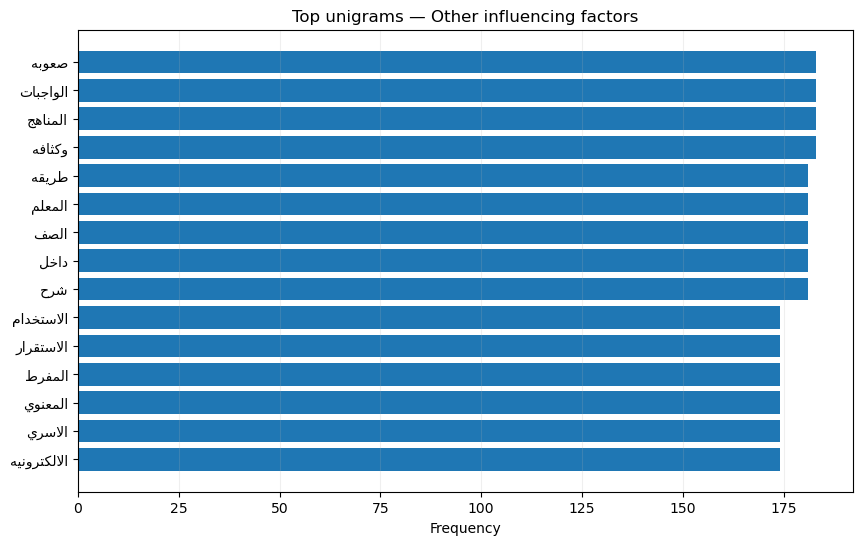

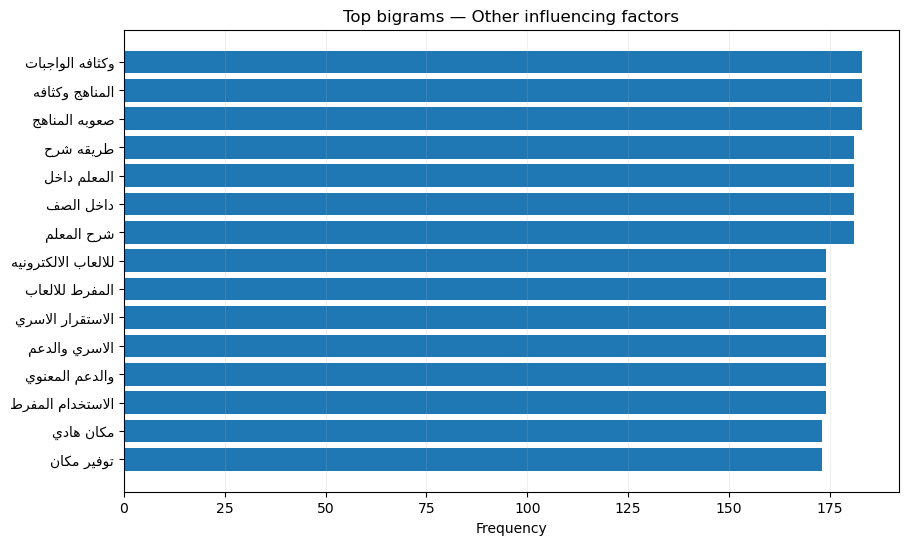

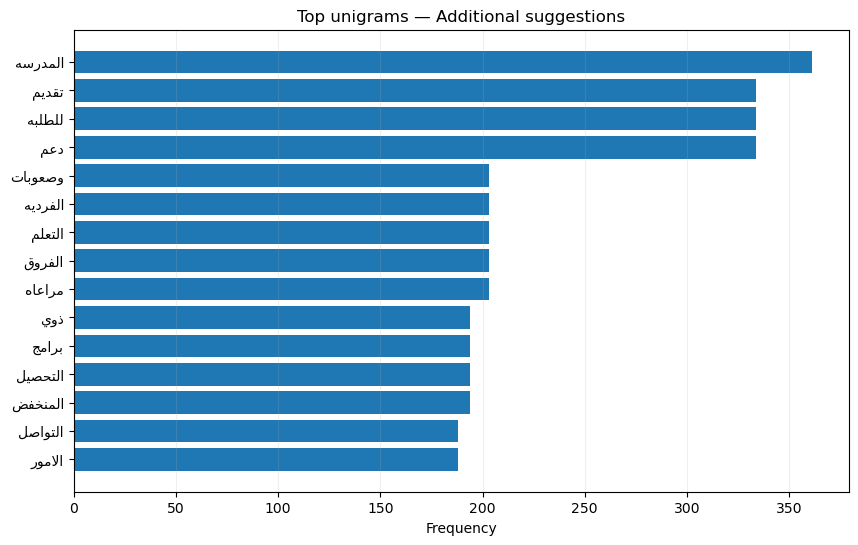

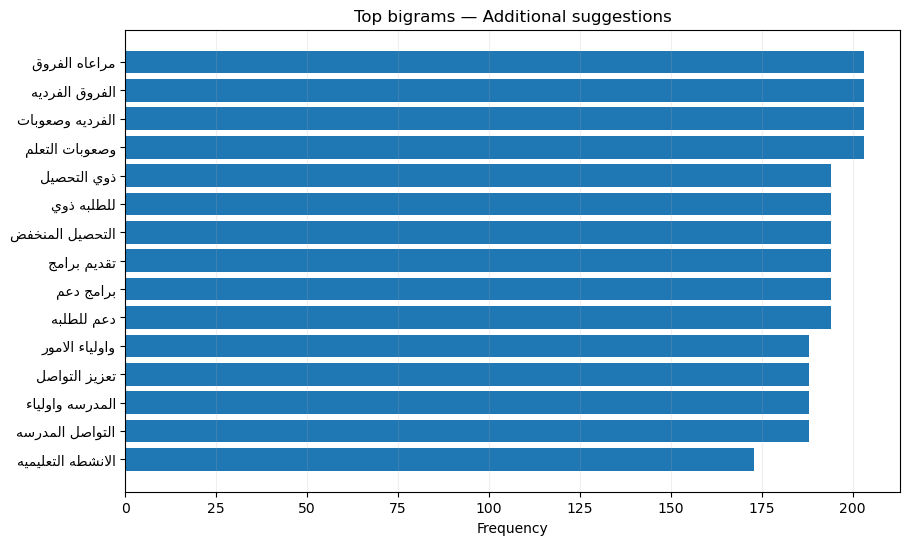

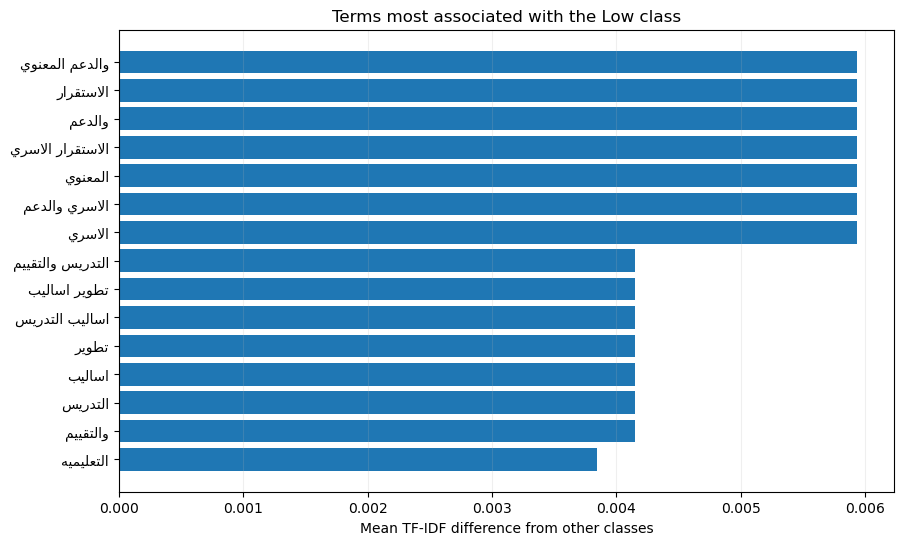

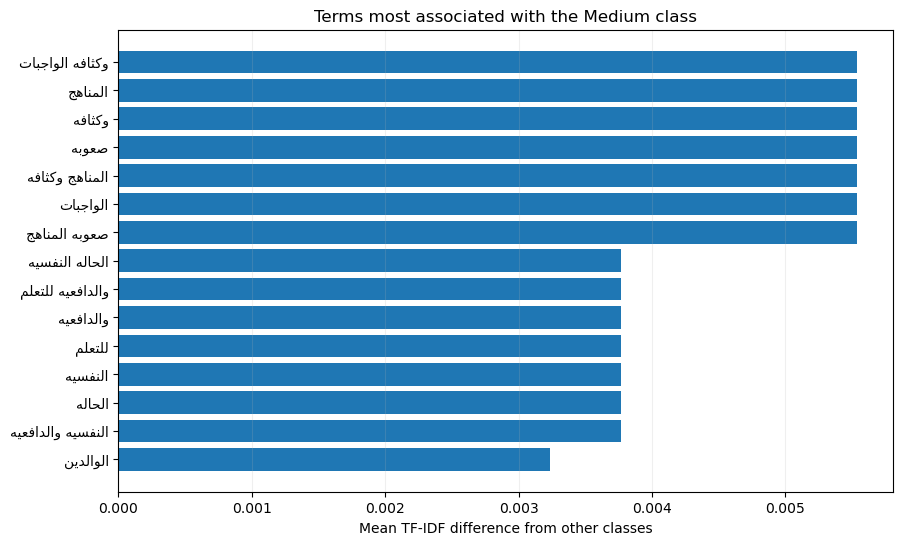

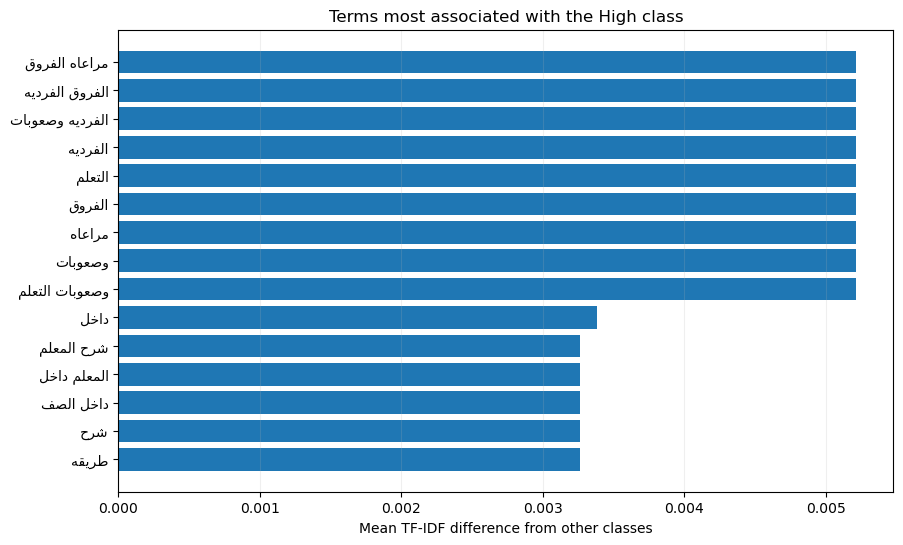

[WindowsPath('C:/Users/User/Desktop/All/outputs/Phase_09_Open_Ended_Responses_and_NLP_Analysis/Section_09_04_Word_Phrase_and_TFIDF_Analysis/Cell_09_04_04_Visualise_Frequent_and_Class_Specific_Terms/tables/09_04_04_visualisation_catalogue.csv'),
 WindowsPath('C:/Users/User/Desktop/All/outputs/Phase_09_Open_Ended_Responses_and_NLP_Analysis/Section_09_04_Word_Phrase_and_TFIDF_Analysis/Cell_09_04_04_Visualise_Frequent_and_Class_Specific_Terms/tables/09_04_04_visualisation_catalogue.xlsx')]

In [12]:
# Cell 9.4.4 — Visualise Frequent and Class-Specific Terms

CELL_FOLDERS = create_cell_folders(
    "09_04", "Word_Phrase_and_TFIDF_Analysis",
    "09_04_04", "Visualise_Frequent_and_Class_Specific_Terms",
)
visualisation_rows = []

for question in TEXT_COLUMNS:
    for ngram_type in ["unigram", "bigram"]:
        subset = term_frequencies.loc[
            term_frequencies["question_column"].eq(question) &
            term_frequencies["ngram_type"].eq(ngram_type)
        ].head(15).sort_values("frequency")
        if subset.empty:
            continue
        figure, axis = plt.subplots(figsize=(10, 6))
        axis.barh([display_text(term) for term in subset["term"]], subset["frequency"])
        axis.set_title(f"Top {ngram_type}s — {question_labels.get(question, question)}")
        axis.set_xlabel("Frequency")
        axis.grid(axis="x", alpha=0.2)
        path = save_figure(figure, CELL_FOLDERS, f"09_04_04_top_{ngram_type}_{safe_name(question)}")
        plt.show()
        plt.close(figure)
        visualisation_rows.append({"figure_name": f"Top {ngram_type} — {question}", "path": str(path)})

for class_name in ["Low", "Medium", "High"]:
    subset = class_specific_terms_all.loc[
        class_specific_terms_all["academic_class"].eq(class_name)
    ].head(15).sort_values("tfidf_difference")
    if subset.empty:
        continue
    figure, axis = plt.subplots(figsize=(10, 6))
    axis.barh([display_text(term) for term in subset["term"]], subset["tfidf_difference"])
    axis.set_title(f"Terms most associated with the {class_name} class")
    axis.set_xlabel("Mean TF-IDF difference from other classes")
    axis.grid(axis="x", alpha=0.2)
    path = save_figure(figure, CELL_FOLDERS, f"09_04_04_class_specific_terms_{class_name.lower()}")
    plt.show()
    plt.close(figure)
    visualisation_rows.append({"figure_name": f"Class-specific terms — {class_name}", "path": str(path)})

visualisation_catalogue_terms = pd.DataFrame(visualisation_rows)
save_dataframe(visualisation_catalogue_terms, CELL_FOLDERS, "09_04_04_visualisation_catalogue")

# Section 9.5 — Topic-Modelling Candidate Search and Final NMF Topics

In [13]:
# Cell 9.5.1 — Search for a Stable and Interpretable Number of NMF Topics

def topic_diversity(model, top_n=10):
    top_indices = [np.argsort(component)[::-1][:top_n] for component in model.components_]
    unique_terms = len(set(np.concatenate(top_indices)))
    return unique_terms / (len(top_indices) * top_n)


def assignment_balance(assignments, k):
    counts = np.bincount(assignments, minlength=k).astype(float)
    proportions = counts / counts.sum()
    entropy = -np.sum(np.where(proportions > 0, proportions * np.log(proportions), 0.0))
    return entropy / np.log(k) if k > 1 else 0.0

unique_text_count = substantive_responses["analysis_text"].nunique()
max_topics_allowed = min(
    TOPIC_K_MAX,
    max(TOPIC_K_MIN, int(round(math.sqrt(unique_text_count))) + 1),
    max(TOPIC_K_MIN, unique_text_count - 1),
    X_word_tfidf.shape[1] - 1,
)
if max_topics_allowed < TOPIC_K_MIN:
    raise ValueError("The corpus does not contain enough variation for topic modelling.")

candidate_rows = []
candidate_models = {}
for k in range(TOPIC_K_MIN, max_topics_allowed + 1):
    seed_assignments = []
    seed_models = []
    seed_errors = []
    for seed in [RANDOM_STATE, RANDOM_STATE + 11, RANDOM_STATE + 29]:
        model = NMF(
            n_components=k,
            init="nndsvda",
            solver="cd",
            beta_loss="frobenius",
            max_iter=800,
            random_state=seed,
            alpha_W=0.001,
            alpha_H=0.001,
            l1_ratio=0.05,
        )
        weights = model.fit_transform(X_word_tfidf)
        assignments = weights.argmax(axis=1)
        seed_assignments.append(assignments)
        seed_models.append((model, weights))
        seed_errors.append(model.reconstruction_err_)

    ari_values = [
        adjusted_rand_score(a, b)
        for a, b in combinations(seed_assignments, 2)
    ]
    best_seed_index = int(np.argmin(seed_errors))
    best_model, best_weights = seed_models[best_seed_index]
    candidate_models[k] = (best_model, best_weights)
    candidate_rows.append({
        "number_of_topics": k,
        "reconstruction_error": float(seed_errors[best_seed_index]),
        "topic_diversity": float(topic_diversity(best_model, TOP_TERMS_PER_TOPIC)),
        "assignment_balance": float(assignment_balance(best_weights.argmax(axis=1), k)),
        "seed_stability_mean_ari": float(np.mean(ari_values)) if ari_values else 1.0,
        "minimum_topic_size": int(np.bincount(best_weights.argmax(axis=1), minlength=k).min()),
    })

topic_model_candidates = pd.DataFrame(candidate_rows)
for metric, ascending in [
    ("reconstruction_error", True),
    ("topic_diversity", False),
    ("assignment_balance", False),
    ("seed_stability_mean_ari", False),
]:
    values = topic_model_candidates[[metric]].to_numpy(dtype=float)
    scaled = MinMaxScaler().fit_transform(values).ravel()
    topic_model_candidates[f"scaled_{metric}"] = 1 - scaled if ascending else scaled

topic_model_candidates["normalised_topic_complexity"] = (
    (topic_model_candidates["number_of_topics"] - TOPIC_K_MIN) /
    max(1, max_topics_allowed - TOPIC_K_MIN)
)
topic_model_candidates["topic_selection_score"] = (
    0.35 * topic_model_candidates["scaled_reconstruction_error"] +
    0.25 * topic_model_candidates["scaled_topic_diversity"] +
    0.25 * topic_model_candidates["scaled_seed_stability_mean_ari"] +
    0.15 * topic_model_candidates["scaled_assignment_balance"] -
    0.20 * topic_model_candidates["normalised_topic_complexity"]
)
SELECTED_TOPIC_K = int(
    topic_model_candidates.sort_values(
        ["topic_selection_score", "topic_diversity", "seed_stability_mean_ari"],
        ascending=[False, False, False],
    ).iloc[0]["number_of_topics"]
)

CELL_FOLDERS = create_cell_folders(
    "09_05", "Topic_Modelling_Candidate_Search_and_Final_NMF_Topics",
    "09_05_01", "Search_for_Number_of_NMF_Topics",
)
save_dataframe(topic_model_candidates, CELL_FOLDERS, "09_05_01_topic_model_candidates")
save_json_report({"selected_topic_k": SELECTED_TOPIC_K}, CELL_FOLDERS, "09_05_01_selected_topic_k")
display(topic_model_candidates.sort_values("number_of_topics"))
print("Selected number of topics:", SELECTED_TOPIC_K)

,number_of_topics,reconstruction_error,topic_diversity,assignment_balance,seed_stability_mean_ari,minimum_topic_size,scaled_reconstruction_error,scaled_topic_diversity,scaled_assignment_balance,scaled_seed_stability_mean_ari,normalised_topic_complexity,topic_selection_score
0,2,51.425091,1.000000,0.352362,1.000000,203,8.881784e-16,1.000000,0.000000,1.0,0.000000,0.500000
1,3,49.454017,0.966667,0.693362,1.000000,203,3.406070e-01,0.166667,0.816856,1.0,0.333333,0.466741
2,4,47.583486,0.975000,0.769816,0.799994,203,6.638399e-01,0.375000,1.000000,0.0,0.666667,0.342761
3,5,45.638146,0.960000,0.683027,1.000000,183,1.000000e+00,0.000000,0.792100,1.0,1.000000,0.518815


Selected number of topics: 5


In [14]:
# Cell 9.5.2 — Fit the Final NMF Model and Create Auditable Topic Labels

final_nmf_model, topic_weights = candidate_models[SELECTED_TOPIC_K]
topic_assignments = topic_weights.argmax(axis=1)
topic_confidence = topic_weights.max(axis=1) / np.maximum(topic_weights.sum(axis=1), 1e-12)

topic_term_rows = []
topic_labels = {}
for topic_index, component in enumerate(final_nmf_model.components_, start=1):
    top_indices = np.argsort(component)[::-1][:TOP_TERMS_PER_TOPIC]
    top_terms = WORD_FEATURE_NAMES[top_indices]
    top_weights = component[top_indices]
    topic_labels[topic_index - 1] = f"Topic {topic_index} — " + " / ".join(top_terms[:3])
    for rank, (term, weight) in enumerate(zip(top_terms, top_weights), start=1):
        topic_term_rows.append({
            "topic_id": topic_index,
            "automatic_topic_label": topic_labels[topic_index - 1],
            "manual_topic_label": "",
            "term_rank": rank,
            "term": term,
            "term_weight": float(weight),
        })

topic_terms = pd.DataFrame(topic_term_rows)
substantive_responses["topic_id"] = topic_assignments + 1
substantive_responses["automatic_topic_label"] = [topic_labels[value] for value in topic_assignments]
substantive_responses["topic_confidence"] = topic_confidence
for topic_index in range(SELECTED_TOPIC_K):
    substantive_responses[f"topic_{topic_index + 1}_weight"] = topic_weights[:, topic_index]

topic_prevalence = (
    substantive_responses.groupby(["topic_id", "automatic_topic_label"])
    .agg(
        response_count=("response_id", "size"),
        mean_topic_confidence=("topic_confidence", "mean"),
        median_topic_confidence=("topic_confidence", "median"),
        unique_response_count=("normalized_text", "nunique"),
    ).reset_index()
)
topic_prevalence["response_percentage"] = topic_prevalence["response_count"] / len(substantive_responses) * 100

CELL_FOLDERS = create_cell_folders(
    "09_05", "Topic_Modelling_Candidate_Search_and_Final_NMF_Topics",
    "09_05_02", "Fit_Final_NMF_and_Create_Topic_Labels",
)
save_dataframe(topic_terms, CELL_FOLDERS, "09_05_02_topic_terms_for_manual_review")
save_dataframe(topic_prevalence, CELL_FOLDERS, "09_05_02_topic_prevalence")
save_dataframe(substantive_responses, CELL_FOLDERS, "09_05_02_responses_with_topic_assignments")
joblib.dump(final_nmf_model, CELL_FOLDERS["files"] / "09_05_02_final_nmf_topic_model.joblib")
display(topic_terms.groupby("topic_id").head(TOP_TERMS_PER_TOPIC))
display(topic_prevalence)

,topic_id,automatic_topic_label,manual_topic_label,term_rank,term,term_weight
0,1,Topic 1 — للطلبه / دعم / تقديم,,1,للطلبه,0.538483
1,1,Topic 1 — للطلبه / دعم / تقديم,,2,دعم,0.538483
2,1,Topic 1 — للطلبه / دعم / تقديم,,3,تقديم,0.538483
3,1,Topic 1 — للطلبه / دعم / تقديم,,4,برامج دعم,0.429345
4,1,Topic 1 — للطلبه / دعم / تقديم,,5,التحصيل,0.429345
5,1,Topic 1 — للطلبه / دعم / تقديم,,6,المنخفض,0.429345
6,1,Topic 1 — للطلبه / دعم / تقديم,,7,ذوي التحصيل,0.429345
7,1,Topic 1 — للطلبه / دعم / تقديم,,8,دعم للطلبه,0.429345
8,1,Topic 1 — للطلبه / دعم / تقديم,,9,برامج,0.429345
9,1,Topic 1 — للطلبه / دعم / تقديم,,10,للطلبه ذوي,0.429345


,topic_id,automatic_topic_label,response_count,mean_topic_confidence,median_topic_confidence,unique_response_count,response_percentage
0,1,Topic 1 — للطلبه / دعم / تقديم,1978,0.168857,0.0,12,64.703958
1,2,Topic 2 — وصعوبات التعلم / وصعوبات / الفروق ال...,203,1.000000,1.0,1,6.640497
2,3,Topic 3 — واولياء الامور / واولياء / الامور,188,1.000000,1.0,1,6.149820
3,4,Topic 4 — داخل / المعلم داخل / المعلم,505,0.962554,1.0,3,16.519464
4,5,Topic 5 — وكثافه الواجبات / وكثافه / المناهج,183,1.000000,1.0,1,5.986261


In [15]:
# Cell 9.5.3 — Analyse Topic Prevalence by Question and Academic Class

topic_by_question = pd.crosstab(
    [substantive_responses["question_column"]],
    substantive_responses["topic_id"],
    normalize="index",
).mul(100).reset_index()

topic_by_class = pd.crosstab(
    [substantive_responses[TARGET_COLUMN]],
    substantive_responses["topic_id"],
    normalize="index",
).mul(100).reset_index()

topic_by_question_and_class = pd.crosstab(
    [substantive_responses["question_column"], substantive_responses[TARGET_COLUMN]],
    substantive_responses["topic_id"],
    normalize="index",
).mul(100).reset_index()

representative_responses = (
    substantive_responses.sort_values("topic_confidence", ascending=False)
    .groupby("topic_id", as_index=False)
    .head(5)[[
        "topic_id", "automatic_topic_label", "question_column", TARGET_COLUMN,
        "topic_confidence", "redacted_excerpt", "pii_flag",
    ]]
)
representative_responses = representative_responses.loc[~representative_responses["pii_flag"]].copy()

CELL_FOLDERS = create_cell_folders(
    "09_05", "Topic_Modelling_Candidate_Search_and_Final_NMF_Topics",
    "09_05_03", "Analyse_Topics_by_Question_and_Class",
)
for name, frame in {
    "09_05_03_topic_by_question_percent": topic_by_question,
    "09_05_03_topic_by_class_percent": topic_by_class,
    "09_05_03_topic_by_question_and_class_percent": topic_by_question_and_class,
    "09_05_03_representative_redacted_responses": representative_responses,
}.items():
    save_dataframe(frame, CELL_FOLDERS, name)
display(topic_by_question_and_class)

topic_id,question_column,academic_performance_class,1,2,3,4,5
0,additional_suggestions,High,57.336957,16.304348,14.130435,12.228261,0.000000
1,additional_suggestions,Low,55.652174,15.942029,14.782609,13.623188,0.000000
2,additional_suggestions,Medium,62.865497,12.865497,12.426901,11.842105,0.000000
3,other_influencing_factors,High,67.250000,0.000000,0.000000,23.000000,9.750000
4,other_influencing_factors,Low,71.428571,0.000000,0.000000,18.735363,9.836066
5,other_influencing_factors,Medium,68.547419,0.000000,0.000000,19.207683,12.244898


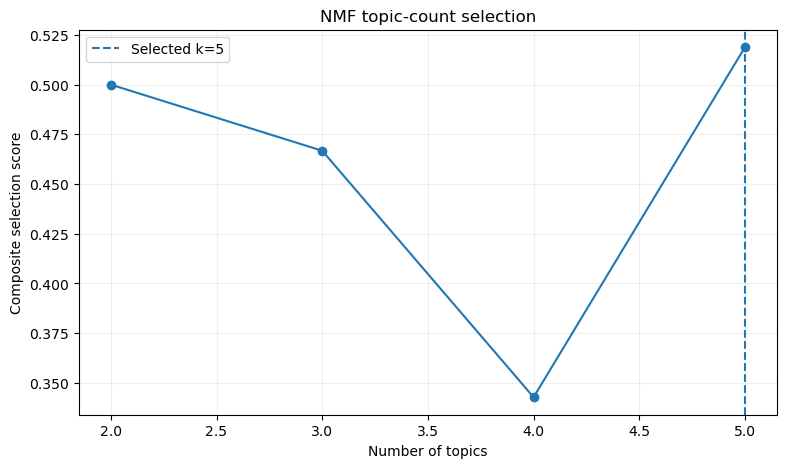

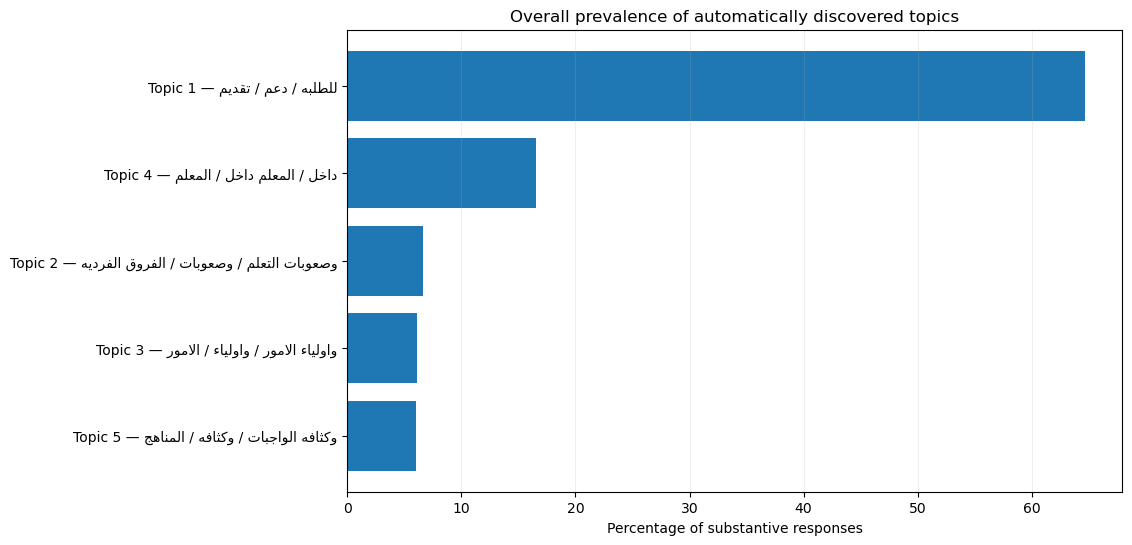

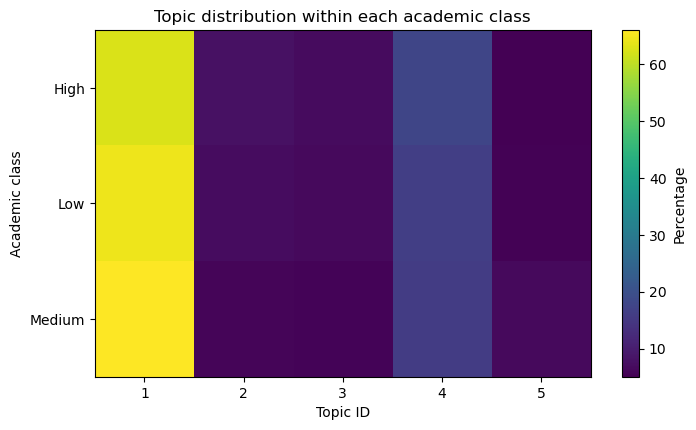

[WindowsPath('C:/Users/User/Desktop/All/outputs/Phase_09_Open_Ended_Responses_and_NLP_Analysis/Section_09_05_Topic_Modelling_Candidate_Search_and_Final_NMF_Topics/Cell_09_05_04_Visualise_Topic_Selection_and_Prevalence/tables/09_05_04_visualisation_catalogue.csv'),
 WindowsPath('C:/Users/User/Desktop/All/outputs/Phase_09_Open_Ended_Responses_and_NLP_Analysis/Section_09_05_Topic_Modelling_Candidate_Search_and_Final_NMF_Topics/Cell_09_05_04_Visualise_Topic_Selection_and_Prevalence/tables/09_05_04_visualisation_catalogue.xlsx')]

In [16]:
# Cell 9.5.4 — Visualise Topic Selection and Topic Prevalence

CELL_FOLDERS = create_cell_folders(
    "09_05", "Topic_Modelling_Candidate_Search_and_Final_NMF_Topics",
    "09_05_04", "Visualise_Topic_Selection_and_Prevalence",
)
visualisation_rows = []

figure, axis = plt.subplots(figsize=(9, 5))
axis.plot(topic_model_candidates["number_of_topics"], topic_model_candidates["topic_selection_score"], marker="o")
axis.axvline(SELECTED_TOPIC_K, linestyle="--", label=f"Selected k={SELECTED_TOPIC_K}")
axis.set_title("NMF topic-count selection")
axis.set_xlabel("Number of topics")
axis.set_ylabel("Composite selection score")
axis.grid(alpha=0.2)
axis.legend()
path = save_figure(figure, CELL_FOLDERS, "09_05_04_topic_count_selection")
plt.show()
plt.close(figure)
visualisation_rows.append({"figure_name": "Topic-count selection", "path": str(path)})

plot_data = topic_prevalence.sort_values("response_count")
figure, axis = plt.subplots(figsize=(10, 6))
axis.barh([display_text(label) for label in plot_data["automatic_topic_label"]], plot_data["response_percentage"])
axis.set_title("Overall prevalence of automatically discovered topics")
axis.set_xlabel("Percentage of substantive responses")
axis.grid(axis="x", alpha=0.2)
path = save_figure(figure, CELL_FOLDERS, "09_05_04_topic_prevalence")
plt.show()
plt.close(figure)
visualisation_rows.append({"figure_name": "Topic prevalence", "path": str(path)})

class_heatmap = topic_by_class.set_index(TARGET_COLUMN)
figure, axis = plt.subplots(figsize=(max(8, SELECTED_TOPIC_K * 1.1), 4.5))
image = axis.imshow(class_heatmap.to_numpy(), aspect="auto")
axis.set_xticks(range(class_heatmap.shape[1]))
axis.set_xticklabels([str(column) for column in class_heatmap.columns])
axis.set_yticks(range(class_heatmap.shape[0]))
axis.set_yticklabels(class_heatmap.index)
axis.set_title("Topic distribution within each academic class")
axis.set_xlabel("Topic ID")
axis.set_ylabel("Academic class")
figure.colorbar(image, ax=axis, label="Percentage")
path = save_figure(figure, CELL_FOLDERS, "09_05_04_topic_by_class_heatmap")
plt.show()
plt.close(figure)
visualisation_rows.append({"figure_name": "Topic by class heatmap", "path": str(path)})

visualisation_catalogue_topics = pd.DataFrame(visualisation_rows)
save_dataframe(visualisation_catalogue_topics, CELL_FOLDERS, "09_05_04_visualisation_catalogue")

# Section 9.6 — Unsupervised Text Clustering and Two-Dimensional Semantic Map

In [17]:
# Cell 9.6.1 — Reduce TF–IDF Dimensionality and Search for Text Clusters

combined_tfidf = hstack([X_word_tfidf, X_char_tfidf], format="csr")
max_components = min(
    MAX_SVD_COMPONENTS,
    combined_tfidf.shape[0] - 1,
    combined_tfidf.shape[1] - 1,
)
if max_components < 2:
    raise ValueError("The corpus is too small for semantic dimensionality reduction.")

svd_components = max(2, max_components)
semantic_reducer = make_pipeline(
    TruncatedSVD(n_components=svd_components, random_state=RANDOM_STATE),
    Normalizer(copy=False),
)
X_semantic = semantic_reducer.fit_transform(combined_tfidf)

unique_semantic_rows = np.unique(np.round(X_semantic, 8), axis=0).shape[0]
max_clusters_allowed = min(
    TEXT_CLUSTER_K_MAX,
    max(TEXT_CLUSTER_K_MIN, int(round(math.sqrt(unique_semantic_rows)))),
    max(TEXT_CLUSTER_K_MIN, unique_semantic_rows - 1),
)
cluster_candidate_rows = []
cluster_models = {}

sample_size = min(SILHOUETTE_SAMPLE_SIZE, len(X_semantic))
rng = np.random.default_rng(RANDOM_STATE)
sample_indices = rng.choice(len(X_semantic), size=sample_size, replace=False)

for k in range(TEXT_CLUSTER_K_MIN, max_clusters_allowed + 1):
    seed_labels = []
    seed_models = []
    for seed in [RANDOM_STATE, RANDOM_STATE + 17, RANDOM_STATE + 41]:
        model = KMeans(
            n_clusters=k,
            random_state=seed,
            n_init=5,
            max_iter=300,
            algorithm="lloyd",
        )
        labels = model.fit_predict(X_semantic)
        seed_labels.append(labels)
        seed_models.append(model)
    stability_values = [adjusted_rand_score(a, b) for a, b in combinations(seed_labels, 2)]
    labels = seed_labels[0]
    model = seed_models[0]
    counts = np.bincount(labels, minlength=k)
    cluster_candidate_rows.append({
        "number_of_clusters": k,
        "silhouette_score": float(silhouette_score(X_semantic[sample_indices], labels[sample_indices])),
        "calinski_harabasz_score": float(calinski_harabasz_score(X_semantic, labels)),
        "davies_bouldin_score": float(davies_bouldin_score(X_semantic, labels)),
        "seed_stability_mean_ari": float(np.mean(stability_values)),
        "minimum_cluster_size": int(counts.min()),
        "maximum_cluster_size": int(counts.max()),
        "cluster_size_ratio": float(counts.min() / counts.max()),
        "inertia": float(model.inertia_),
    })
    cluster_models[k] = model

text_cluster_candidates = pd.DataFrame(cluster_candidate_rows)
metric_direction = {
    "silhouette_score": False,
    "calinski_harabasz_score": False,
    "davies_bouldin_score": True,
    "seed_stability_mean_ari": False,
    "cluster_size_ratio": False,
}
for metric, lower_is_better in metric_direction.items():
    scaled = MinMaxScaler().fit_transform(text_cluster_candidates[[metric]]).ravel()
    text_cluster_candidates[f"scaled_{metric}"] = 1 - scaled if lower_is_better else scaled
text_cluster_candidates["cluster_selection_score"] = (
    0.35 * text_cluster_candidates["scaled_silhouette_score"] +
    0.20 * text_cluster_candidates["scaled_calinski_harabasz_score"] +
    0.15 * text_cluster_candidates["scaled_davies_bouldin_score"] +
    0.20 * text_cluster_candidates["scaled_seed_stability_mean_ari"] +
    0.10 * text_cluster_candidates["scaled_cluster_size_ratio"]
)
SELECTED_TEXT_CLUSTER_K = int(
    text_cluster_candidates.sort_values(
        ["cluster_selection_score", "silhouette_score", "seed_stability_mean_ari"],
        ascending=[False, False, False],
    ).iloc[0]["number_of_clusters"]
)

CELL_FOLDERS = create_cell_folders(
    "09_06", "Unsupervised_Text_Clustering_and_Semantic_Map",
    "09_06_01", "Reduce_Dimensionality_and_Search_Text_Clusters",
)
save_dataframe(text_cluster_candidates, CELL_FOLDERS, "09_06_01_text_cluster_candidates")
save_json_report({
    "selected_text_cluster_k": SELECTED_TEXT_CLUSTER_K,
    "svd_components": svd_components,
}, CELL_FOLDERS, "09_06_01_selected_text_cluster_configuration")
display(text_cluster_candidates)
print("Selected number of text clusters:", SELECTED_TEXT_CLUSTER_K)

,number_of_clusters,silhouette_score,calinski_harabasz_score,davies_bouldin_score,seed_stability_mean_ari,minimum_cluster_size,maximum_cluster_size,cluster_size_ratio,inertia,scaled_silhouette_score,scaled_calinski_harabasz_score,scaled_davies_bouldin_score,scaled_seed_stability_mean_ari,scaled_cluster_size_ratio,cluster_selection_score
0,2,0.117060,214.781569,3.668791,0.018186,1201,1856,0.647091,2654.201890,0.000000,0.00000,0.000000,0.0000,1.00000,0.100000
1,3,0.176786,226.727820,3.073977,0.094361,552,1530,0.360784,2473.536520,0.539945,0.30648,0.500938,0.2678,0.33137,0.412114
2,4,0.227676,253.760418,2.481390,0.302632,336,1535,0.218893,2273.817329,1.000000,1.00000,1.000000,1.0000,0.00000,0.900000


Selected number of text clusters: 4


In [18]:
# Cell 9.6.2 — Fit Final Text Clusters and Create Cluster Profiles

final_text_cluster_model = cluster_models[SELECTED_TEXT_CLUSTER_K]
text_cluster_labels = final_text_cluster_model.predict(X_semantic)
substantive_responses["text_cluster_id"] = text_cluster_labels + 1

distances = final_text_cluster_model.transform(X_semantic)
substantive_responses["distance_to_text_cluster_centroid"] = distances.min(axis=1)

cluster_term_rows = []
for cluster_id in range(1, SELECTED_TEXT_CLUSTER_K + 1):
    mask = substantive_responses["text_cluster_id"].eq(cluster_id).to_numpy()
    cluster_mean = np.asarray(X_word_tfidf[mask].mean(axis=0)).ravel()
    other_mean = np.asarray(X_word_tfidf[~mask].mean(axis=0)).ravel() if (~mask).any() else np.zeros_like(cluster_mean)
    difference = cluster_mean - other_mean
    top_indices = np.argsort(difference)[::-1][:TOP_TERMS_PER_TOPIC]
    for rank, index in enumerate(top_indices, start=1):
        cluster_term_rows.append({
            "text_cluster_id": cluster_id,
            "term_rank": rank,
            "term": WORD_FEATURE_NAMES[index],
            "cluster_mean_tfidf": cluster_mean[index],
            "other_clusters_mean_tfidf": other_mean[index],
            "tfidf_difference": difference[index],
        })
text_cluster_terms = pd.DataFrame(cluster_term_rows)

text_cluster_profiles = (
    substantive_responses.groupby("text_cluster_id")
    .agg(
        response_count=("response_id", "size"),
        unique_response_count=("normalized_text", "nunique"),
        mean_token_count=("token_count_analysis", "mean"),
        mean_centroid_distance=("distance_to_text_cluster_centroid", "mean"),
        dominant_topic=("topic_id", lambda s: s.value_counts().index[0]),
        dominant_question=("question_column", lambda s: s.value_counts().index[0]),
        dominant_academic_class=(TARGET_COLUMN, lambda s: s.value_counts().index[0]),
    ).reset_index()
)
text_cluster_profiles["response_percentage"] = text_cluster_profiles["response_count"] / len(substantive_responses) * 100

CELL_FOLDERS = create_cell_folders(
    "09_06", "Unsupervised_Text_Clustering_and_Semantic_Map",
    "09_06_02", "Fit_Final_Text_Clusters_and_Create_Profiles",
)
save_dataframe(text_cluster_profiles, CELL_FOLDERS, "09_06_02_text_cluster_profiles")
save_dataframe(text_cluster_terms, CELL_FOLDERS, "09_06_02_text_cluster_terms")
save_dataframe(substantive_responses, CELL_FOLDERS, "09_06_02_responses_with_topics_and_clusters")
joblib.dump(semantic_reducer, CELL_FOLDERS["files"] / "09_06_02_semantic_reducer.joblib")
joblib.dump(final_text_cluster_model, CELL_FOLDERS["files"] / "09_06_02_final_text_cluster_model.joblib")
display(text_cluster_profiles)
display(text_cluster_terms.groupby("text_cluster_id").head(8))

,text_cluster_id,response_count,unique_response_count,mean_token_count,mean_centroid_distance,dominant_topic,dominant_question,dominant_academic_class,response_percentage
0,1,336,2,5.000000,0.650960,1,other_influencing_factors,Medium,10.991168
1,2,1535,9,4.599349,0.932155,4,other_influencing_factors,Medium,50.212627
2,3,519,3,4.658960,0.794576,1,other_influencing_factors,Medium,16.977429
3,4,667,4,5.082459,0.837311,1,additional_suggestions,Medium,21.818777


,text_cluster_id,term_rank,term,cluster_mean_tfidf,other_clusters_mean_tfidf,tfidf_difference
0,1,1,توفير,0.279377,0.0,0.279377
1,1,2,ومناسب,0.174689,0.0,0.174689
2,1,3,توفير مكان,0.174689,0.0,0.174689
3,1,4,مكان هادي,0.174689,0.0,0.174689
4,1,5,للدراسه,0.174689,0.0,0.174689
5,1,6,هادي,0.174689,0.0,0.174689
6,1,7,مكان,0.174689,0.0,0.174689
7,1,8,هادي ومناسب,0.174689,0.0,0.174689
10,2,1,المدرسه,0.063270,0.0,0.063270
11,2,2,داخل,0.062055,0.0,0.062055


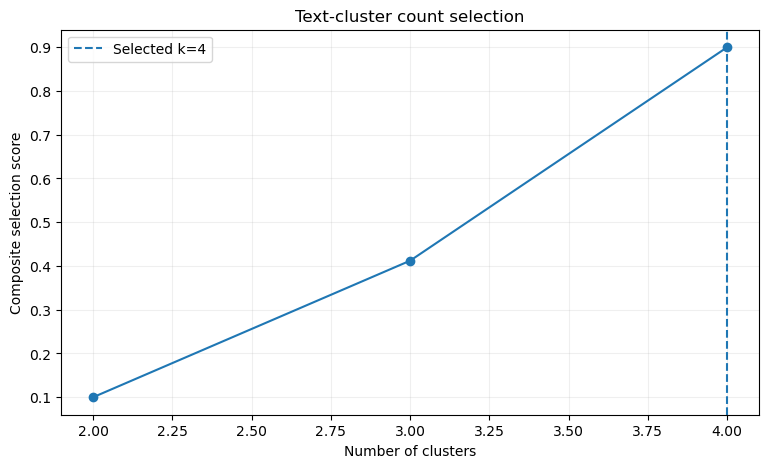

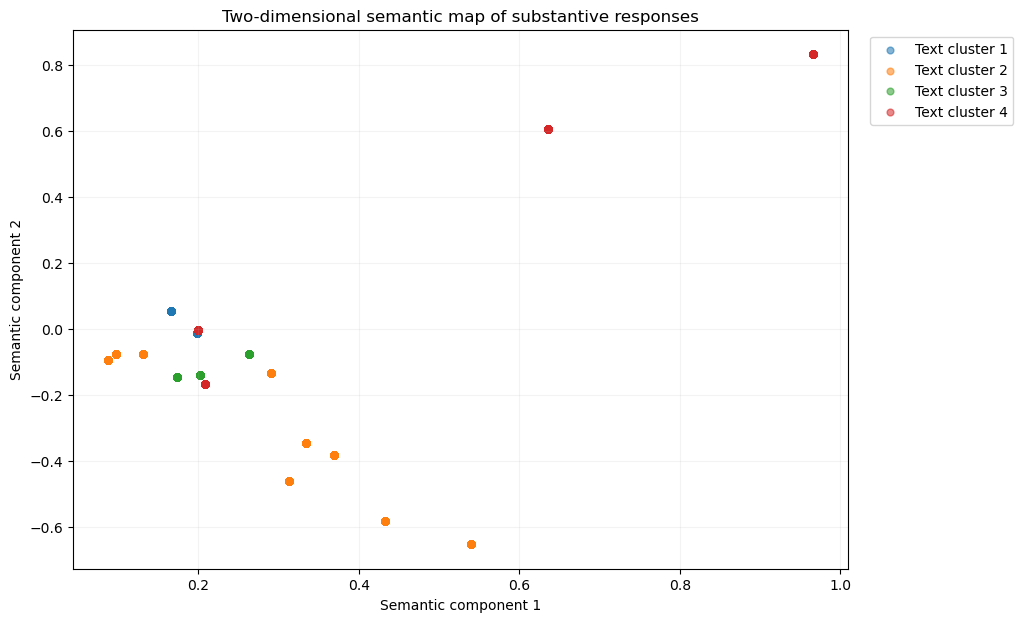

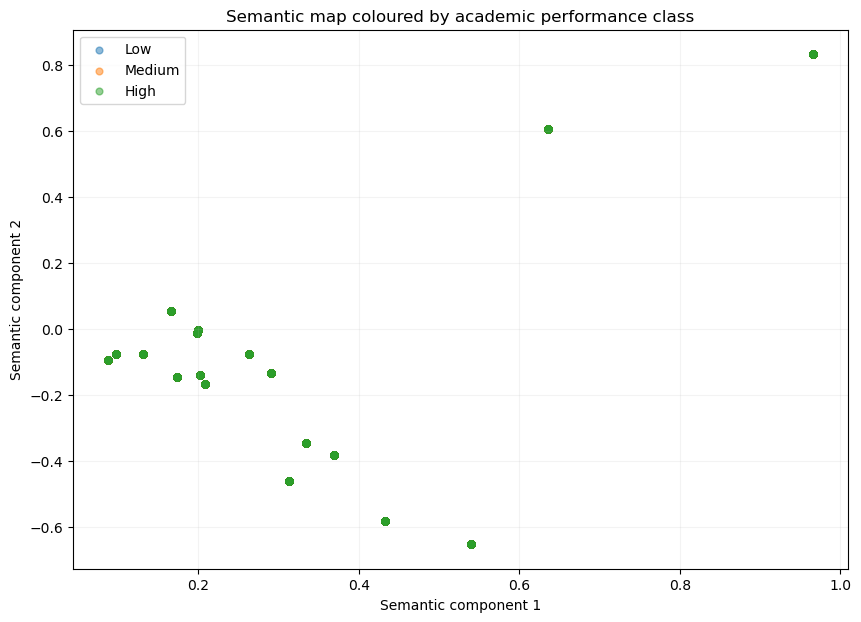

[WindowsPath('C:/Users/User/Desktop/All/outputs/Phase_09_Open_Ended_Responses_and_NLP_Analysis/Section_09_06_Unsupervised_Text_Clustering_and_Semantic_Map/Cell_09_06_03_Create_Two_Dimensional_Semantic_Map/tables/09_06_03_visualisation_catalogue.csv'),
 WindowsPath('C:/Users/User/Desktop/All/outputs/Phase_09_Open_Ended_Responses_and_NLP_Analysis/Section_09_06_Unsupervised_Text_Clustering_and_Semantic_Map/Cell_09_06_03_Create_Two_Dimensional_Semantic_Map/tables/09_06_03_visualisation_catalogue.xlsx')]

In [19]:
# Cell 9.6.3 — Create a Two-Dimensional Semantic Map and Cluster Diagnostics

semantic_2d_reducer = TruncatedSVD(n_components=2, random_state=RANDOM_STATE)
X_semantic_2d = semantic_2d_reducer.fit_transform(combined_tfidf)
substantive_responses["semantic_component_1"] = X_semantic_2d[:, 0]
substantive_responses["semantic_component_2"] = X_semantic_2d[:, 1]

CELL_FOLDERS = create_cell_folders(
    "09_06", "Unsupervised_Text_Clustering_and_Semantic_Map",
    "09_06_03", "Create_Two_Dimensional_Semantic_Map",
)
visualisation_rows = []

figure, axis = plt.subplots(figsize=(9, 5))
axis.plot(
    text_cluster_candidates["number_of_clusters"],
    text_cluster_candidates["cluster_selection_score"],
    marker="o",
)
axis.axvline(SELECTED_TEXT_CLUSTER_K, linestyle="--", label=f"Selected k={SELECTED_TEXT_CLUSTER_K}")
axis.set_title("Text-cluster count selection")
axis.set_xlabel("Number of clusters")
axis.set_ylabel("Composite selection score")
axis.grid(alpha=0.2)
axis.legend()
path = save_figure(figure, CELL_FOLDERS, "09_06_03_text_cluster_selection")
plt.show()
plt.close(figure)
visualisation_rows.append({"figure_name": "Text-cluster selection", "path": str(path)})

figure, axis = plt.subplots(figsize=(10, 7))
for cluster_id in sorted(substantive_responses["text_cluster_id"].unique()):
    subset = substantive_responses.loc[substantive_responses["text_cluster_id"].eq(cluster_id)]
    axis.scatter(
        subset["semantic_component_1"],
        subset["semantic_component_2"],
        s=24,
        alpha=0.55,
        label=f"Text cluster {cluster_id}",
    )
axis.set_title("Two-dimensional semantic map of substantive responses")
axis.set_xlabel("Semantic component 1")
axis.set_ylabel("Semantic component 2")
axis.grid(alpha=0.15)
axis.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
path = save_figure(figure, CELL_FOLDERS, "09_06_03_semantic_map_by_text_cluster")
plt.show()
plt.close(figure)
visualisation_rows.append({"figure_name": "Semantic map by text cluster", "path": str(path)})

figure, axis = plt.subplots(figsize=(10, 7))
for class_name in ["Low", "Medium", "High"]:
    subset = substantive_responses.loc[substantive_responses[TARGET_COLUMN].eq(class_name)]
    if subset.empty:
        continue
    axis.scatter(
        subset["semantic_component_1"],
        subset["semantic_component_2"],
        s=24,
        alpha=0.5,
        label=class_name,
    )
axis.set_title("Semantic map coloured by academic performance class")
axis.set_xlabel("Semantic component 1")
axis.set_ylabel("Semantic component 2")
axis.grid(alpha=0.15)
axis.legend()
path = save_figure(figure, CELL_FOLDERS, "09_06_03_semantic_map_by_academic_class")
plt.show()
plt.close(figure)
visualisation_rows.append({"figure_name": "Semantic map by academic class", "path": str(path)})

visualisation_catalogue_clusters = pd.DataFrame(visualisation_rows)
save_dataframe(visualisation_catalogue_clusters, CELL_FOLDERS, "09_06_03_visualisation_catalogue")

# Section 9.7 — Exploratory Lexical Polarity and Recommendation Orientation

In [20]:
# Cell 9.7.1 — Calculate an Exploratory Lexical Polarity Indicator

POSITIVE_TERMS = {
    "دعم", "تشجيع", "تحفيز", "تحسين", "تطوير", "تعزيز", "مساعده", "مساعدة",
    "استقرار", "نجاح", "تفوق", "ايجابي", "إيجابي", "مناسب", "جيد", "ممتاز",
    "support", "encourage", "improve", "development", "positive", "success", "help",
}
NEGATIVE_TERMS = {
    "صعوبه", "صعوبة", "ضغط", "مشكله", "مشكلة", "ضعف", "قلق", "خوف", "تنمر",
    "مرض", "ارهاق", "إرهاق", "فقر", "بطاله", "بطالة", "عنف", "اهمال", "إهمال",
    "مفرط", "ادمان", "إدمان", "قلة", "نقص", "سلبي", "سيئ", "رسوب",
    "difficulty", "problem", "stress", "anxiety", "negative", "poor", "failure", "lack",
}
ACTION_TERMS = {
    "توفير", "تقديم", "زياده", "زيادة", "تنظيم", "تطوير", "تعزيز", "مراعاه", "مراعاة",
    "انشاء", "إنشاء", "تفعيل", "تحسين", "تقليل", "متابعه", "متابعة", "دعم", "تخصيص",
    "provide", "increase", "organise", "organize", "develop", "reduce", "support", "create",
}
NEGATORS = {"لا", "ليس", "غير", "بدون", "not", "no", "without"}


def lexical_indicators(text):
    tokens = tokenize(text, remove_stopwords=False)
    positive = 0
    negative = 0
    action = 0
    for index, token in enumerate(tokens):
        negated = index > 0 and tokens[index - 1] in NEGATORS
        if token in POSITIVE_TERMS:
            negative += 1 if negated else 0
            positive += 0 if negated else 1
        if token in NEGATIVE_TERMS:
            positive += 1 if negated else 0
            negative += 0 if negated else 1
        if token in ACTION_TERMS:
            action += 1
    denominator = max(1, positive + negative)
    polarity = (positive - negative) / denominator
    if polarity > 0.20:
        polarity_label = "Positive/supportive language"
    elif polarity < -0.20:
        polarity_label = "Concern/negative language"
    else:
        polarity_label = "Neutral/mixed language"
    return positive, negative, action, polarity, polarity_label

if ENABLE_EXPLORATORY_LEXICAL_POLARITY:
    lexical_values = substantive_responses["normalized_text"].map(lexical_indicators)
    substantive_responses[[
        "positive_term_count", "negative_term_count", "action_term_count",
        "lexical_polarity_score", "lexical_polarity_label",
    ]] = pd.DataFrame(lexical_values.tolist(), index=substantive_responses.index)
else:
    for column in [
        "positive_term_count", "negative_term_count", "action_term_count",
        "lexical_polarity_score", "lexical_polarity_label",
    ]:
        substantive_responses[column] = pd.NA

polarity_summary = (
    substantive_responses.groupby(["question_column", TARGET_COLUMN, "lexical_polarity_label"])
    .size().rename("response_count").reset_index()
)
polarity_summary["percentage_within_question_and_class"] = (
    polarity_summary["response_count"] /
    polarity_summary.groupby(["question_column", TARGET_COLUMN])["response_count"].transform("sum") * 100
)

action_orientation = (
    substantive_responses.groupby(["question_column", TARGET_COLUMN])
    .agg(
        response_count=("response_id", "size"),
        mean_action_term_count=("action_term_count", "mean"),
        responses_with_action_language=("action_term_count", lambda s: int((s > 0).sum())),
        mean_lexical_polarity=("lexical_polarity_score", "mean"),
    ).reset_index()
)
action_orientation["action_oriented_percentage"] = (
    action_orientation["responses_with_action_language"] / action_orientation["response_count"] * 100
)

CELL_FOLDERS = create_cell_folders(
    "09_07", "Exploratory_Lexical_Polarity_and_Recommendation_Orientation",
    "09_07_01", "Calculate_Exploratory_Lexical_Indicators",
)
save_dataframe(polarity_summary, CELL_FOLDERS, "09_07_01_lexical_polarity_summary")
save_dataframe(action_orientation, CELL_FOLDERS, "09_07_01_action_orientation_summary")
display(polarity_summary)
display(action_orientation)

,question_column,academic_performance_class,lexical_polarity_label,response_count,percentage_within_question_and_class
0,additional_suggestions,High,Neutral/mixed language,194,52.717391
1,additional_suggestions,High,Positive/supportive language,174,47.282609
2,additional_suggestions,Low,Neutral/mixed language,172,49.855072
3,additional_suggestions,Low,Positive/supportive language,173,50.144928
4,additional_suggestions,Medium,Neutral/mixed language,344,50.292398
5,additional_suggestions,Medium,Positive/supportive language,340,49.707602
6,other_influencing_factors,High,Concern/negative language,39,9.750000
7,other_influencing_factors,High,Neutral/mixed language,332,83.000000
8,other_influencing_factors,High,Positive/supportive language,29,7.250000
9,other_influencing_factors,Low,Concern/negative language,42,9.836066


,question_column,academic_performance_class,response_count,mean_action_term_count,responses_with_action_language,mean_lexical_polarity,action_oriented_percentage
0,additional_suggestions,High,368,1.239130,368,0.472826,100.000000
1,additional_suggestions,Low,345,1.214493,345,0.501449,100.000000
2,additional_suggestions,Medium,684,1.251462,684,0.497076,100.000000
3,other_influencing_factors,High,400,0.110000,44,-0.025000,11.000000
4,other_influencing_factors,Low,427,0.112412,48,-0.014052,11.241218
5,other_influencing_factors,Medium,833,0.097239,81,-0.030012,9.723890


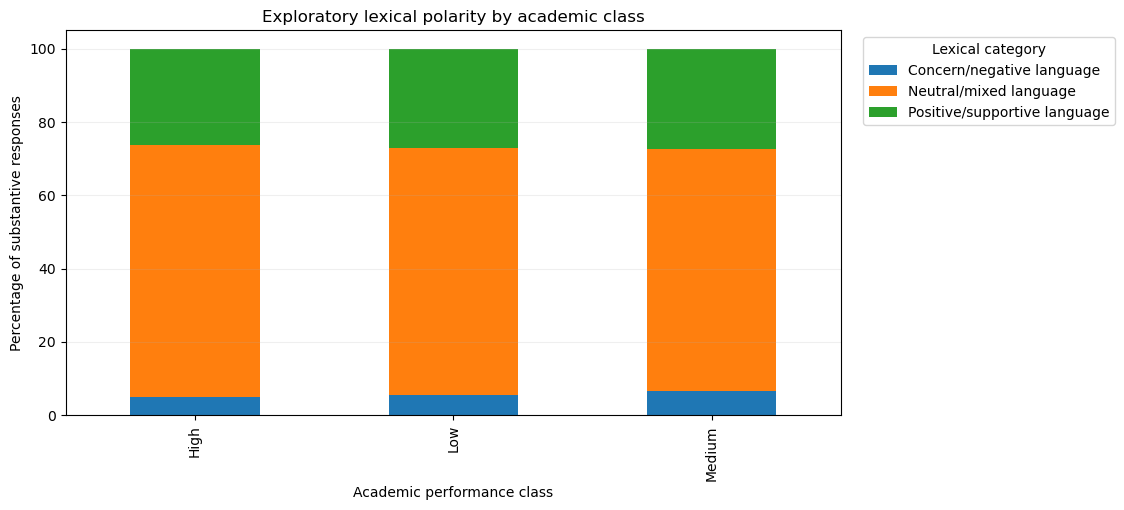

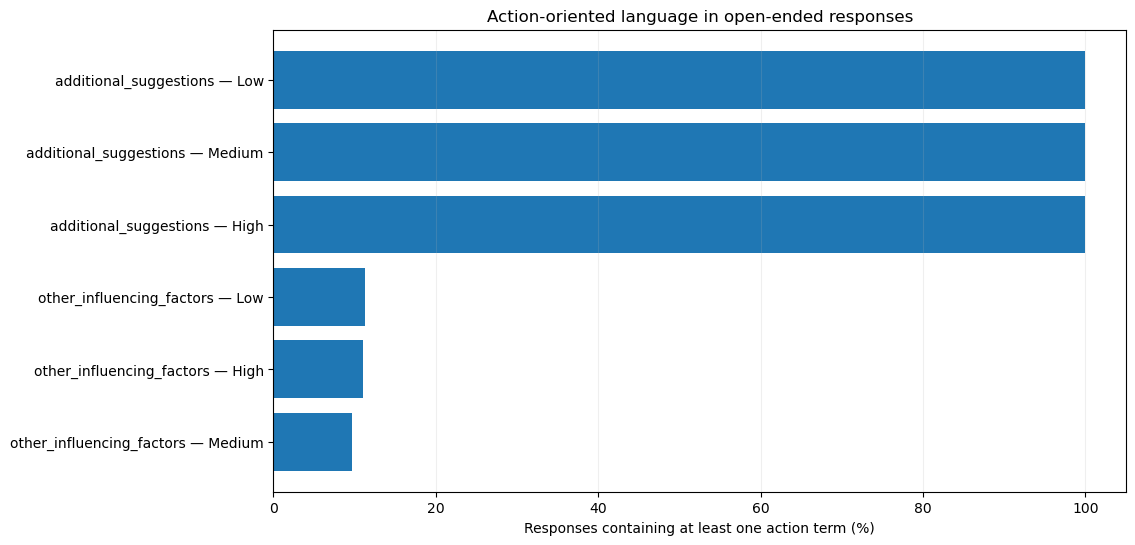

[WindowsPath('C:/Users/User/Desktop/All/outputs/Phase_09_Open_Ended_Responses_and_NLP_Analysis/Section_09_07_Exploratory_Lexical_Polarity_and_Recommendation_Orientation/Cell_09_07_02_Visualise_Lexical_Polarity_and_Action_Language/tables/09_07_02_visualisation_catalogue.csv'),
 WindowsPath('C:/Users/User/Desktop/All/outputs/Phase_09_Open_Ended_Responses_and_NLP_Analysis/Section_09_07_Exploratory_Lexical_Polarity_and_Recommendation_Orientation/Cell_09_07_02_Visualise_Lexical_Polarity_and_Action_Language/tables/09_07_02_visualisation_catalogue.xlsx')]

In [21]:
# Cell 9.7.2 — Visualise Lexical Polarity and Action-Oriented Language

CELL_FOLDERS = create_cell_folders(
    "09_07", "Exploratory_Lexical_Polarity_and_Recommendation_Orientation",
    "09_07_02", "Visualise_Lexical_Polarity_and_Action_Language",
)
visualisation_rows = []

plot_data = (
    substantive_responses.groupby([TARGET_COLUMN, "lexical_polarity_label"])
    .size().rename("count").reset_index()
)
plot_data["percentage"] = plot_data["count"] / plot_data.groupby(TARGET_COLUMN)["count"].transform("sum") * 100
plot_pivot = plot_data.pivot(index=TARGET_COLUMN, columns="lexical_polarity_label", values="percentage").fillna(0)
figure, axis = plt.subplots(figsize=(10, 5))
plot_pivot.plot(kind="bar", stacked=True, ax=axis)
axis.set_title("Exploratory lexical polarity by academic class")
axis.set_xlabel("Academic performance class")
axis.set_ylabel("Percentage of substantive responses")
axis.legend(title="Lexical category", bbox_to_anchor=(1.02, 1), loc="upper left")
axis.grid(axis="y", alpha=0.2)
path = save_figure(figure, CELL_FOLDERS, "09_07_02_lexical_polarity_by_class")
plt.show()
plt.close(figure)
visualisation_rows.append({"figure_name": "Lexical polarity by class", "path": str(path)})

plot_data = action_orientation.copy()
plot_data["label"] = plot_data["question_column"] + " — " + plot_data[TARGET_COLUMN].astype(str)
plot_data = plot_data.sort_values("action_oriented_percentage")
figure, axis = plt.subplots(figsize=(11, 6))
axis.barh(plot_data["label"], plot_data["action_oriented_percentage"])
axis.set_title("Action-oriented language in open-ended responses")
axis.set_xlabel("Responses containing at least one action term (%)")
axis.grid(axis="x", alpha=0.2)
path = save_figure(figure, CELL_FOLDERS, "09_07_02_action_oriented_language")
plt.show()
plt.close(figure)
visualisation_rows.append({"figure_name": "Action-oriented language", "path": str(path)})

visualisation_catalogue_polarity = pd.DataFrame(visualisation_rows)
save_dataframe(visualisation_catalogue_polarity, CELL_FOLDERS, "09_07_02_visualisation_catalogue")

# Section 9.8 — Statistical Associations with Academic Class and Phase 5 Clusters

In [22]:
# Cell 9.8.1 — Define Statistical Tests and Multiple-Testing Correction

def cramers_v(contingency):
    table = np.asarray(contingency, dtype=float)
    if table.size == 0 or table.sum() == 0:
        return np.nan
    chi2 = stats.chi2_contingency(table, correction=False)[0]
    n = table.sum()
    rows, columns = table.shape
    phi2 = chi2 / n
    phi2_corrected = max(0.0, phi2 - ((columns - 1) * (rows - 1)) / max(1, n - 1))
    rows_corrected = rows - ((rows - 1) ** 2) / max(1, n - 1)
    columns_corrected = columns - ((columns - 1) ** 2) / max(1, n - 1)
    denominator = min(columns_corrected - 1, rows_corrected - 1)
    return math.sqrt(phi2_corrected / denominator) if denominator > 0 else np.nan


def epsilon_squared_kruskal(groups):
    groups = [np.asarray(group) for group in groups if len(group) > 0]
    if len(groups) < 2:
        return np.nan
    statistic, _ = stats.kruskal(*groups)
    n = sum(len(group) for group in groups)
    k = len(groups)
    return max(0.0, (statistic - k + 1) / max(1, n - k))


def benjamini_hochberg(p_values):
    p_values = np.asarray(p_values, dtype=float)
    adjusted = np.full(len(p_values), np.nan)
    valid = np.isfinite(p_values)
    valid_values = p_values[valid]
    if valid_values.size == 0:
        return adjusted
    order = np.argsort(valid_values)
    ranked = valid_values[order]
    m = len(ranked)
    adjusted_ranked = ranked * m / np.arange(1, m + 1)
    adjusted_ranked = np.minimum.accumulate(adjusted_ranked[::-1])[::-1]
    adjusted_ranked = np.clip(adjusted_ranked, 0, 1)
    valid_indices = np.where(valid)[0]
    adjusted[valid_indices[order]] = adjusted_ranked
    return adjusted

print("Statistical helper functions configured.")

Statistical helper functions configured.


In [23]:
# Cell 9.8.2 — Test Response Status, Length, Topics, and Text Clusters against Academic Class

statistical_rows = []

for question in TEXT_COLUMNS:
    subset_all = responses_long.loc[responses_long["question_column"].eq(question)]
    status_table = pd.crosstab(subset_all[TARGET_COLUMN], subset_all["response_status"])
    if status_table.shape[0] > 1 and status_table.shape[1] > 1:
        chi2, p_value, dof, _ = stats.chi2_contingency(status_table)
        statistical_rows.append({
            "analysis_family": "Response status",
            "question_column": question,
            "variables": f"{TARGET_COLUMN} × response_status",
            "test": "Chi-square test of independence",
            "statistic": chi2,
            "degrees_of_freedom": dof,
            "p_value": p_value,
            "effect_size_name": "Cramer's V",
            "effect_size": cramers_v(status_table),
            "sample_size": int(status_table.to_numpy().sum()),
        })

    subset = substantive_responses.loc[substantive_responses["question_column"].eq(question)]
    groups = [
        subset.loc[subset[TARGET_COLUMN].eq(class_name), "token_count_analysis"].to_numpy()
        for class_name in ["Low", "Medium", "High"]
        if subset[TARGET_COLUMN].eq(class_name).any()
    ]
    if len(groups) > 1:
        statistic, p_value = stats.kruskal(*groups)
        statistical_rows.append({
            "analysis_family": "Response length",
            "question_column": question,
            "variables": f"{TARGET_COLUMN} × token_count_analysis",
            "test": "Kruskal-Wallis H test",
            "statistic": statistic,
            "degrees_of_freedom": len(groups) - 1,
            "p_value": p_value,
            "effect_size_name": "Epsilon squared",
            "effect_size": epsilon_squared_kruskal(groups),
            "sample_size": int(sum(len(group) for group in groups)),
        })

    for categorical_column, family_name in [
        ("topic_id", "NMF topic"),
        ("text_cluster_id", "Text cluster"),
        ("lexical_polarity_label", "Lexical polarity"),
    ]:
        contingency = pd.crosstab(subset[TARGET_COLUMN], subset[categorical_column])
        if contingency.shape[0] > 1 and contingency.shape[1] > 1:
            chi2, p_value, dof, _ = stats.chi2_contingency(contingency)
            statistical_rows.append({
                "analysis_family": family_name,
                "question_column": question,
                "variables": f"{TARGET_COLUMN} × {categorical_column}",
                "test": "Chi-square test of independence",
                "statistic": chi2,
                "degrees_of_freedom": dof,
                "p_value": p_value,
                "effect_size_name": "Cramer's V",
                "effect_size": cramers_v(contingency),
                "sample_size": int(contingency.to_numpy().sum()),
            })

statistical_tests = pd.DataFrame(statistical_rows)
statistical_tests["p_value_bh_adjusted"] = benjamini_hochberg(statistical_tests["p_value"])
statistical_tests["significant_at_0_05_after_bh"] = statistical_tests["p_value_bh_adjusted"] < 0.05

CELL_FOLDERS = create_cell_folders(
    "09_08", "Statistical_Associations_with_Class_and_Phase_5_Clusters",
    "09_08_02", "Test_NLP_Results_against_Academic_Class",
)
save_dataframe(statistical_tests, CELL_FOLDERS, "09_08_02_statistical_tests_academic_class")
display(statistical_tests.sort_values("p_value_bh_adjusted"))

,analysis_family,question_column,variables,test,statistic,degrees_of_freedom,p_value,effect_size_name,effect_size,sample_size,p_value_bh_adjusted,significant_at_0_05_after_bh
5,Response status,additional_suggestions,academic_performance_class × response_status,Chi-square test of independence,10.086626,4,0.038993,Cramer's V,0.034900,2500,0.389935,False
2,NMF topic,other_influencing_factors,academic_performance_class × topic_id,Chi-square test of independence,5.232066,4,0.264304,Cramer's V,0.019257,1660,0.618261,False
4,Lexical polarity,other_influencing_factors,academic_performance_class × lexical_polarity_...,Chi-square test of independence,4.327660,4,0.363474,Cramer's V,0.009904,1660,0.618261,False
6,Response length,additional_suggestions,academic_performance_class × token_count_analysis,Kruskal-Wallis H test,1.983340,2,0.370957,Epsilon squared,0.000000,1397,0.618261,False
7,NMF topic,additional_suggestions,academic_performance_class × topic_id,Chi-square test of independence,6.726735,6,0.346860,Cramer's V,0.016092,1397,0.618261,False
8,Text cluster,additional_suggestions,academic_performance_class × text_cluster_id,Chi-square test of independence,7.758038,6,0.256371,Cramer's V,0.025072,1397,0.618261,False
0,Response status,other_influencing_factors,academic_performance_class × response_status,Chi-square test of independence,3.741416,4,0.442131,Cramer's V,0.000000,2500,0.631616,False
1,Response length,other_influencing_factors,academic_performance_class × token_count_analysis,Kruskal-Wallis H test,1.227760,2,0.541247,Epsilon squared,0.000000,1660,0.676558,False
9,Lexical polarity,additional_suggestions,academic_performance_class × lexical_polarity_...,Chi-square test of independence,0.734777,2,0.692540,Cramer's V,0.000000,1397,0.769489,False
3,Text cluster,other_influencing_factors,academic_performance_class × text_cluster_id,Chi-square test of independence,2.962397,6,0.813551,Cramer's V,0.000000,1660,0.813551,False


In [24]:
# Cell 9.8.3 — Optionally Merge Phase 5 Student Clusters and Analyse NLP Themes

def resolve_phase_5_cluster_dataset():
    if PHASE_5_CLUSTER_DATA_OVERRIDE is not None:
        path = Path(PHASE_5_CLUSTER_DATA_OVERRIDE).expanduser()
        return path if path.exists() else None
    candidates = [
        DATA_DIR / "phase_05_cluster_assignments.csv",
        PROJECT_ROOT / "phase_05_cluster_assignments.csv",
        Path.cwd() / "data" / "phase_05_cluster_assignments.csv",
        Path.cwd() / "phase_05_cluster_assignments.csv",
    ]
    if PHASE_5_DIR.exists():
        candidates.extend(PHASE_5_DIR.rglob("phase_05_cluster_assignments.csv"))
    for candidate in candidates:
        if Path(candidate).exists():
            return Path(candidate)
    return None

PHASE_5_CLUSTER_PATH = resolve_phase_5_cluster_dataset()
if PHASE_5_CLUSTER_PATH is not None:
    phase_5_clusters = load_table(PHASE_5_CLUSTER_PATH)
    keep_columns = [column for column in [IDENTIFIER_COLUMN, "cluster_id", "cluster_name"] if column in phase_5_clusters.columns]
    substantive_responses = substantive_responses.merge(
        phase_5_clusters[keep_columns].drop_duplicates(IDENTIFIER_COLUMN),
        how="left",
        on=IDENTIFIER_COLUMN,
        validate="many_to_one",
    )
    cluster_coverage = substantive_responses["cluster_id"].notna().mean()
    topic_by_phase_5_cluster = pd.crosstab(
        substantive_responses["cluster_name"].fillna("Not available"),
        substantive_responses["topic_id"],
        normalize="index",
    ).mul(100).reset_index()

    available = substantive_responses.dropna(subset=["cluster_id"])
    contingency = pd.crosstab(available["cluster_id"], available["topic_id"])
    if contingency.shape[0] > 1 and contingency.shape[1] > 1:
        chi2, p_value, dof, _ = stats.chi2_contingency(contingency)
        phase_5_topic_test = pd.DataFrame([{
            "variables": "Phase 5 student cluster × Phase 9 NMF topic",
            "test": "Chi-square test of independence",
            "statistic": chi2,
            "degrees_of_freedom": dof,
            "p_value": p_value,
            "effect_size_name": "Cramer's V",
            "effect_size": cramers_v(contingency),
            "sample_size": int(contingency.to_numpy().sum()),
        }])
    else:
        phase_5_topic_test = pd.DataFrame()
else:
    phase_5_clusters = pd.DataFrame()
    topic_by_phase_5_cluster = pd.DataFrame()
    phase_5_topic_test = pd.DataFrame()
    cluster_coverage = 0.0

CELL_FOLDERS = create_cell_folders(
    "09_08", "Statistical_Associations_with_Class_and_Phase_5_Clusters",
    "09_08_03", "Merge_Phase_5_Clusters_and_Analyse_NLP_Themes",
)
save_dataframe(topic_by_phase_5_cluster, CELL_FOLDERS, "09_08_03_topic_by_phase_5_cluster")
save_dataframe(phase_5_topic_test, CELL_FOLDERS, "09_08_03_phase_5_cluster_topic_test")
save_json_report({
    "phase_5_cluster_path": str(PHASE_5_CLUSTER_PATH) if PHASE_5_CLUSTER_PATH else None,
    "phase_5_cluster_merge_coverage": float(cluster_coverage),
}, CELL_FOLDERS, "09_08_03_phase_5_merge_summary")
print("Phase 5 cluster dataset:", PHASE_5_CLUSTER_PATH)
print("Cluster merge coverage among substantive responses:", round(cluster_coverage, 4))
if not topic_by_phase_5_cluster.empty:
    display(topic_by_phase_5_cluster)

Phase 5 cluster dataset: C:\Users\User\Desktop\All\data\phase_05_cluster_assignments.csv
Cluster merge coverage among substantive responses: 0.7991


topic_id,cluster_name,1,2,3,4,5
0,Cluster 1 — Higher relative support,65.136612,7.868852,6.338798,16.174863,4.480874
1,Cluster 2 — Moderate relative support,62.080537,6.711409,6.935123,17.449664,6.823266
2,Cluster 3 — Lower relative support,65.299685,5.362776,5.835962,16.561514,6.940063
3,Not available,67.263844,6.026059,5.048860,15.635179,6.026059


# Section 9.9 — Integrated Visualisations and Interpretation Tables

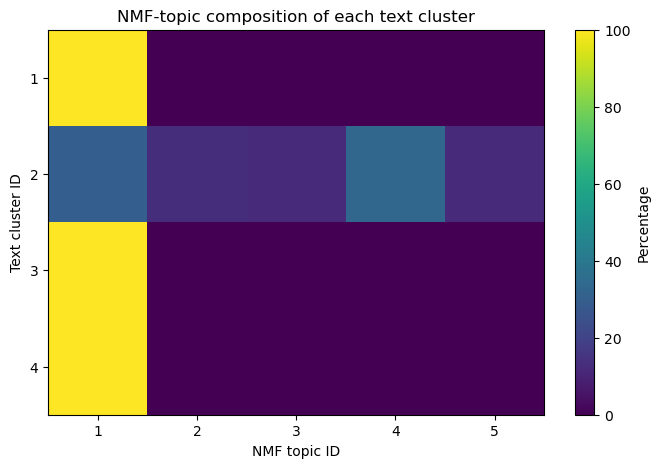

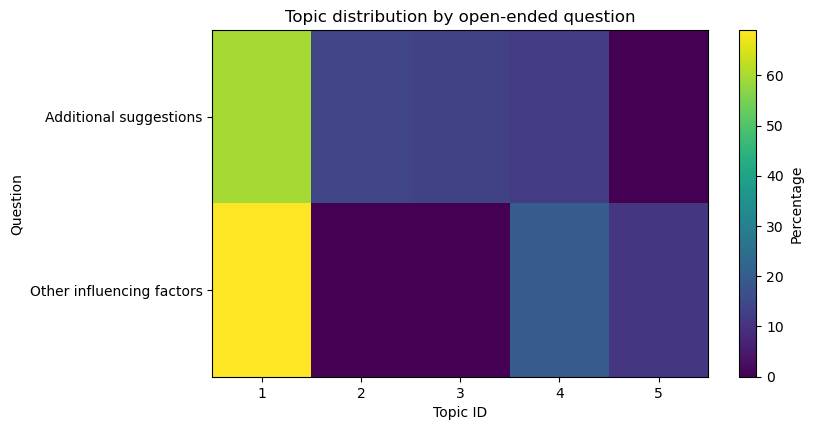

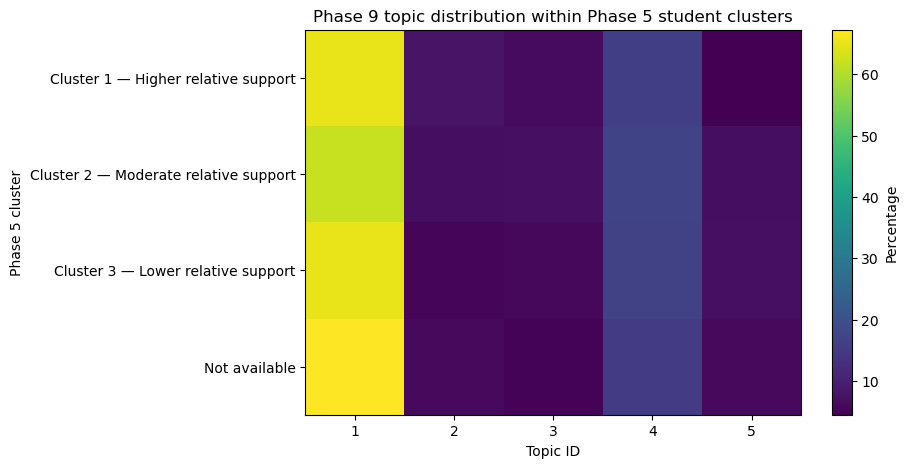

[WindowsPath('C:/Users/User/Desktop/All/outputs/Phase_09_Open_Ended_Responses_and_NLP_Analysis/Section_09_09_Integrated_Visualisations_and_Interpretation_Tables/Cell_09_09_01_Create_Integrated_Visualisations/tables/09_09_01_visualisation_catalogue.csv'),
 WindowsPath('C:/Users/User/Desktop/All/outputs/Phase_09_Open_Ended_Responses_and_NLP_Analysis/Section_09_09_Integrated_Visualisations_and_Interpretation_Tables/Cell_09_09_01_Create_Integrated_Visualisations/tables/09_09_01_visualisation_catalogue.xlsx')]

In [25]:
# Cell 9.9.1 — Create Integrated Topic, Cluster, and Class Visualisations

CELL_FOLDERS = create_cell_folders(
    "09_09", "Integrated_Visualisations_and_Interpretation_Tables",
    "09_09_01", "Create_Integrated_Visualisations",
)
visualisation_rows = []

cluster_topic = pd.crosstab(
    substantive_responses["text_cluster_id"],
    substantive_responses["topic_id"],
    normalize="index",
).mul(100)
figure, axis = plt.subplots(figsize=(max(8, SELECTED_TOPIC_K * 1.1), max(5, SELECTED_TEXT_CLUSTER_K * 0.7)))
image = axis.imshow(cluster_topic.to_numpy(), aspect="auto")
axis.set_xticks(range(cluster_topic.shape[1]))
axis.set_xticklabels(cluster_topic.columns)
axis.set_yticks(range(cluster_topic.shape[0]))
axis.set_yticklabels(cluster_topic.index)
axis.set_title("NMF-topic composition of each text cluster")
axis.set_xlabel("NMF topic ID")
axis.set_ylabel("Text cluster ID")
figure.colorbar(image, ax=axis, label="Percentage")
path = save_figure(figure, CELL_FOLDERS, "09_09_01_topic_composition_by_text_cluster")
plt.show()
plt.close(figure)
visualisation_rows.append({"figure_name": "Topic composition by text cluster", "path": str(path)})

question_topic = pd.crosstab(
    substantive_responses["question_label"],
    substantive_responses["topic_id"],
    normalize="index",
).mul(100)
figure, axis = plt.subplots(figsize=(max(8, SELECTED_TOPIC_K * 1.1), 4.5))
image = axis.imshow(question_topic.to_numpy(), aspect="auto")
axis.set_xticks(range(question_topic.shape[1]))
axis.set_xticklabels(question_topic.columns)
axis.set_yticks(range(question_topic.shape[0]))
axis.set_yticklabels(question_topic.index)
axis.set_title("Topic distribution by open-ended question")
axis.set_xlabel("Topic ID")
axis.set_ylabel("Question")
figure.colorbar(image, ax=axis, label="Percentage")
path = save_figure(figure, CELL_FOLDERS, "09_09_01_topic_distribution_by_question")
plt.show()
plt.close(figure)
visualisation_rows.append({"figure_name": "Topic distribution by question", "path": str(path)})

if not topic_by_phase_5_cluster.empty:
    phase5_heatmap = topic_by_phase_5_cluster.set_index("cluster_name")
    figure, axis = plt.subplots(figsize=(max(8, SELECTED_TOPIC_K * 1.1), max(5, len(phase5_heatmap) * 0.8)))
    image = axis.imshow(phase5_heatmap.to_numpy(), aspect="auto")
    axis.set_xticks(range(phase5_heatmap.shape[1]))
    axis.set_xticklabels(phase5_heatmap.columns)
    axis.set_yticks(range(phase5_heatmap.shape[0]))
    axis.set_yticklabels([display_text(value) for value in phase5_heatmap.index])
    axis.set_title("Phase 9 topic distribution within Phase 5 student clusters")
    axis.set_xlabel("Topic ID")
    axis.set_ylabel("Phase 5 cluster")
    figure.colorbar(image, ax=axis, label="Percentage")
    path = save_figure(figure, CELL_FOLDERS, "09_09_01_topics_within_phase_5_clusters")
    plt.show()
    plt.close(figure)
    visualisation_rows.append({"figure_name": "Topics within Phase 5 clusters", "path": str(path)})

visualisation_catalogue_integrated = pd.DataFrame(visualisation_rows)
save_dataframe(visualisation_catalogue_integrated, CELL_FOLDERS, "09_09_01_visualisation_catalogue")

In [26]:
# Cell 9.9.2 — Build Thesis-Ready Interpretation Tables without Claiming Causality

key_findings_rows = []

for _, row in question_quality.iterrows():
    key_findings_rows.append({
        "finding_type": "Response coverage",
        "scope": row["question_label"],
        "finding": (
            f"{row['substantive_response_rate']:.1%} of questionnaire records supplied a "
            "substantive response after missing and non-substantive answers were separated."
        ),
        "interpretation_limit": "Response provision may reflect willingness to answer and should not be interpreted causally.",
    })

for _, row in topic_prevalence.sort_values("response_percentage", ascending=False).head(min(5, len(topic_prevalence))).iterrows():
    key_findings_rows.append({
        "finding_type": "Topic prevalence",
        "scope": row["automatic_topic_label"],
        "finding": f"The topic represented {row['response_percentage']:.1f}% of substantive responses.",
        "interpretation_limit": "Automatic topic labels are based on weighted terms and require human qualitative review.",
    })

for _, row in statistical_tests.sort_values("p_value_bh_adjusted").head(min(8, len(statistical_tests))).iterrows():
    significance_text = "showed evidence of association" if row["significant_at_0_05_after_bh"] else "did not show evidence of association"
    key_findings_rows.append({
        "finding_type": "Statistical association",
        "scope": f"{row['analysis_family']} — {row['question_column']}",
        "finding": (
            f"{row['variables']} {significance_text} after Benjamini-Hochberg correction "
            f"(adjusted p={row['p_value_bh_adjusted']:.4g}; {row['effect_size_name']}={row['effect_size']:.3f})."
        ),
        "interpretation_limit": "Association does not establish causation and may be influenced by response repetition or sample composition.",
    })

thesis_ready_findings = pd.DataFrame(key_findings_rows)
manual_topic_review_template = (
    topic_terms.groupby(["topic_id", "automatic_topic_label"])["term"]
    .apply(lambda s: ", ".join(s.head(TOP_TERMS_PER_TOPIC)))
    .reset_index(name="top_terms")
)
manual_topic_review_template["researcher_confirmed_topic_name"] = ""
manual_topic_review_template["researcher_interpretation"] = ""
manual_topic_review_template["include_in_thesis"] = "Pending review"

CELL_FOLDERS = create_cell_folders(
    "09_09", "Integrated_Visualisations_and_Interpretation_Tables",
    "09_09_02", "Build_Thesis_Ready_Interpretation_Tables",
)
save_dataframe(thesis_ready_findings, CELL_FOLDERS, "09_09_02_thesis_ready_findings")
save_dataframe(manual_topic_review_template, CELL_FOLDERS, "09_09_02_manual_topic_review_template")
display(thesis_ready_findings)
display(manual_topic_review_template)

,finding_type,scope,finding,interpretation_limit
0,Response coverage,Additional suggestions,55.9% of questionnaire records supplied a subs...,Response provision may reflect willingness to ...
1,Response coverage,Other influencing factors,66.4% of questionnaire records supplied a subs...,Response provision may reflect willingness to ...
2,Topic prevalence,Topic 1 — للطلبه / دعم / تقديم,The topic represented 64.7% of substantive res...,Automatic topic labels are based on weighted t...
3,Topic prevalence,Topic 4 — داخل / المعلم داخل / المعلم,The topic represented 16.5% of substantive res...,Automatic topic labels are based on weighted t...
4,Topic prevalence,Topic 2 — وصعوبات التعلم / وصعوبات / الفروق ال...,The topic represented 6.6% of substantive resp...,Automatic topic labels are based on weighted t...
5,Topic prevalence,Topic 3 — واولياء الامور / واولياء / الامور,The topic represented 6.1% of substantive resp...,Automatic topic labels are based on weighted t...
6,Topic prevalence,Topic 5 — وكثافه الواجبات / وكثافه / المناهج,The topic represented 6.0% of substantive resp...,Automatic topic labels are based on weighted t...
7,Statistical association,Response status — additional_suggestions,academic_performance_class × response_status d...,Association does not establish causation and m...
8,Statistical association,NMF topic — other_influencing_factors,academic_performance_class × topic_id did not ...,Association does not establish causation and m...
9,Statistical association,Lexical polarity — other_influencing_factors,academic_performance_class × lexical_polarity_...,Association does not establish causation and m...


,topic_id,automatic_topic_label,top_terms,researcher_confirmed_topic_name,researcher_interpretation,include_in_thesis
0,1,Topic 1 — للطلبه / دعم / تقديم,"للطلبه, دعم, تقديم, برامج دعم, التحصيل, المنخف...",,,Pending review
1,2,Topic 2 — وصعوبات التعلم / وصعوبات / الفروق ال...,"وصعوبات التعلم, وصعوبات, الفروق الفرديه, الفرد...",,,Pending review
2,3,Topic 3 — واولياء الامور / واولياء / الامور,"واولياء الامور, واولياء, الامور, التواصل المدر...",,,Pending review
3,4,Topic 4 — داخل / المعلم داخل / المعلم,"داخل, المعلم داخل, المعلم, طريقه شرح, داخل الص...",,,Pending review
4,5,Topic 5 — وكثافه الواجبات / وكثافه / المناهج,"وكثافه الواجبات, وكثافه, المناهج, صعوبه, المنا...",,,Pending review


# Section 9.10 — Quality Checks, Consolidated Exports, and Phase 10 Handoff

In [27]:
# Cell 9.10.1 — Run Final Quality Checks

quality_checks = []
def add_check(name, passed, details):
    quality_checks.append({"quality_check": name, "passed": bool(passed), "details": details})

add_check("Phase 2 input hash verified", HASH_MATCH, INPUT_SHA256)
add_check("Required Phase 9 columns are present", not missing_columns, missing_columns)
add_check("Response IDs are unique", responses_long["response_id"].is_unique, int(responses_long["response_id"].duplicated().sum()))
add_check("Substantive corpus is not empty", len(substantive_responses) > 0, len(substantive_responses))
add_check("No missing analysis text in substantive corpus", substantive_responses["analysis_text"].str.len().gt(0).all(), int(substantive_responses["analysis_text"].str.len().eq(0).sum()))
add_check("All substantive responses have a topic assignment", substantive_responses["topic_id"].notna().all(), int(substantive_responses["topic_id"].isna().sum()))
add_check("All substantive responses have a text-cluster assignment", substantive_responses["text_cluster_id"].notna().all(), int(substantive_responses["text_cluster_id"].isna().sum()))
add_check("Topic probabilities are finite", np.isfinite(topic_weights).all(), str(topic_weights.shape))
add_check("Possible PII patterns were redacted before export", True, int(responses_long["pii_flag"].sum()))
add_check("Phase 8 holdout was not loaded", True, "Phase 9 reads the Phase 2 NLP handoff only")
add_check("Statistical p-values were multiplicity-adjusted", "p_value_bh_adjusted" in statistical_tests.columns, len(statistical_tests))

corpus_repetition_warning = bool((duplication_summary["duplicated_row_ratio"].fillna(0) > 0.50).any())
add_check(
    "Corpus repetition level documented",
    True,
    "High repetition detected; interpret topic stability carefully" if corpus_repetition_warning else "No extreme repetition warning",
)

phase_9_quality_checks = pd.DataFrame(quality_checks)
CELL_FOLDERS = create_cell_folders(
    "09_10", "Quality_Checks_Exports_and_Phase_10_Handoff",
    "09_10_01", "Run_Final_Quality_Checks",
)
save_dataframe(phase_9_quality_checks, CELL_FOLDERS, "09_10_01_phase_9_quality_checks")
save_json_report(quality_checks, CELL_FOLDERS, "09_10_01_phase_9_quality_checks")
display(phase_9_quality_checks)

if not phase_9_quality_checks["passed"].all():
    failed = phase_9_quality_checks.loc[~phase_9_quality_checks["passed"], "quality_check"].tolist()
    raise AssertionError("Phase 9 quality checks failed: " + "; ".join(failed))

,quality_check,passed,details
0,Phase 2 input hash verified,True,c796b93f57ace93fc06c7681c3c99707dc8556fc167cd6...
1,Required Phase 9 columns are present,True,[]
2,Response IDs are unique,True,0
3,Substantive corpus is not empty,True,3057
4,No missing analysis text in substantive corpus,True,0
5,All substantive responses have a topic assignment,True,0
6,All substantive responses have a text-cluster ...,True,0
7,Topic probabilities are finite,True,"(3057, 5)"
8,Possible PII patterns were redacted before export,True,0
9,Phase 8 holdout was not loaded,True,Phase 9 reads the Phase 2 NLP handoff only


In [28]:
# Cell 9.10.2 — Export Portable Phase 9 Tables, Models, and Consolidated Workbook

CELL_FOLDERS = create_cell_folders(
    "09_10", "Quality_Checks_Exports_and_Phase_10_Handoff",
    "09_10_02", "Export_Portable_Tables_Models_and_Workbook",
)

portable_tables = {
    "phase_09_all_response_audit": responses_long,
    "phase_09_substantive_responses_with_nlp_results": substantive_responses,
    "phase_09_question_quality_summary": question_quality,
    "phase_09_duplication_summary": duplication_summary,
    "phase_09_term_frequencies": term_frequencies,
    "phase_09_class_specific_terms": class_specific_terms_all,
    "phase_09_topic_model_candidates": topic_model_candidates,
    "phase_09_topic_terms": topic_terms,
    "phase_09_topic_prevalence": topic_prevalence,
    "phase_09_topic_by_class": topic_by_class,
    "phase_09_text_cluster_candidates": text_cluster_candidates,
    "phase_09_text_cluster_profiles": text_cluster_profiles,
    "phase_09_text_cluster_terms": text_cluster_terms,
    "phase_09_lexical_polarity_summary": polarity_summary,
    "phase_09_statistical_tests": statistical_tests,
    "phase_09_topic_by_phase_5_cluster": topic_by_phase_5_cluster,
    "phase_09_thesis_ready_findings": thesis_ready_findings,
    "phase_09_manual_topic_review_template": manual_topic_review_template,
    "phase_09_quality_checks": phase_9_quality_checks,
}

portable_paths = {}
for stem, frame in portable_tables.items():
    csv_path = DATA_DIR / f"{stem}.csv"
    frame.to_csv(csv_path, index=False, encoding="utf-8-sig")
    portable_paths[stem] = str(csv_path)

model_paths = {
    "word_tfidf_vectorizer": DATA_DIR / "phase_09_word_tfidf_vectorizer.joblib",
    "character_tfidf_vectorizer": DATA_DIR / "phase_09_character_tfidf_vectorizer.joblib",
    "nmf_topic_model": DATA_DIR / "phase_09_nmf_topic_model.joblib",
    "semantic_reducer": DATA_DIR / "phase_09_semantic_reducer.joblib",
    "text_cluster_model": DATA_DIR / "phase_09_text_cluster_model.joblib",
    "semantic_2d_reducer": DATA_DIR / "phase_09_semantic_2d_reducer.joblib",
}
joblib.dump(word_tfidf_vectorizer, model_paths["word_tfidf_vectorizer"])
joblib.dump(char_tfidf_vectorizer, model_paths["character_tfidf_vectorizer"])
joblib.dump(final_nmf_model, model_paths["nmf_topic_model"])
joblib.dump(semantic_reducer, model_paths["semantic_reducer"])
joblib.dump(final_text_cluster_model, model_paths["text_cluster_model"])
joblib.dump(semantic_2d_reducer, model_paths["semantic_2d_reducer"])

CONSOLIDATED_WORKBOOK_PATH = PROJECT_ROOT / "Phase_09_Consolidated_Reports.xlsx"
if EXPORT_EXCEL_WORKBOOK:
    sheet_map = {
        "Question Quality": question_quality,
        "Response Coverage": coverage,
        "Duplication Summary": duplication_summary,
        "Top Terms": term_frequencies,
        "Class Terms": class_specific_terms_all,
        "Topic Candidates": topic_model_candidates,
        "Topic Terms": topic_terms,
        "Topic Prevalence": topic_prevalence,
        "Topic by Class": topic_by_class,
        "Text Cluster Candidates": text_cluster_candidates,
        "Text Cluster Profiles": text_cluster_profiles,
        "Statistical Tests": statistical_tests,
        "Phase5 Topic Profiles": topic_by_phase_5_cluster,
        "Thesis Findings": thesis_ready_findings,
        "Manual Topic Review": manual_topic_review_template,
        "Quality Checks": phase_9_quality_checks,
    }
    with pd.ExcelWriter(CONSOLIDATED_WORKBOOK_PATH, engine="openpyxl") as writer:
        for sheet_name, frame in sheet_map.items():
            frame.to_excel(writer, sheet_name=sheet_name[:31], index=False)
else:
    CONSOLIDATED_WORKBOOK_PATH = None

export_summary = {
    "portable_tables": portable_paths,
    "model_paths": {name: str(path) for name, path in model_paths.items()},
    "consolidated_workbook": str(CONSOLIDATED_WORKBOOK_PATH) if CONSOLIDATED_WORKBOOK_PATH else None,
}
save_json_report(export_summary, CELL_FOLDERS, "09_10_02_export_summary")
print("Portable CSV tables exported:", len(portable_paths))
print("Saved NLP artefacts:", len(model_paths))
print("Consolidated workbook:", CONSOLIDATED_WORKBOOK_PATH)

Portable CSV tables exported: 19
Saved NLP artefacts: 6
Consolidated workbook: C:\Users\User\Desktop\All\Phase_09_Consolidated_Reports.xlsx


In [29]:
# Cell 9.10.3 — Create Visualisation Catalogue, Phase 10 Handoff, and Complete ZIP

CELL_FOLDERS = create_cell_folders(
    "09_10", "Quality_Checks_Exports_and_Phase_10_Handoff",
    "09_10_03", "Create_Visualisation_Catalogue_Handoff_and_ZIP",
)

all_figure_paths = sorted(PHASE_DIR.rglob("*.png"))
visualisation_catalogue = pd.DataFrame([
    {
        "figure_number": number,
        "figure_name": path.stem,
        "relative_path": str(path.relative_to(PHASE_DIR)),
        "file_size_kb": round(path.stat().st_size / 1024, 2),
    }
    for number, path in enumerate(all_figure_paths, start=1)
])
save_dataframe(visualisation_catalogue, CELL_FOLDERS, "09_10_03_visualisation_catalogue")

phase_10_handoff = {
    "completed_phase": "Phase 9 — Open-Ended Responses and NLP Analysis",
    "next_phase": "Phase 10 — Final Results Integration and Thesis Reporting",
    "phase_2_nlp_input": str(PHASE_2_NLP_DATA_PATH),
    "phase_2_nlp_input_sha256": INPUT_SHA256,
    "records_in_phase_2_nlp_dataset": int(len(nlp_wide)),
    "all_response_rows": int(len(responses_long)),
    "substantive_response_rows": int(len(substantive_responses)),
    "text_columns": TEXT_COLUMNS,
    "selected_nmf_topics": SELECTED_TOPIC_K,
    "selected_text_clusters": SELECTED_TEXT_CLUSTER_K,
    "phase_5_cluster_path": str(PHASE_5_CLUSTER_PATH) if PHASE_5_CLUSTER_PATH else None,
    "phase_5_cluster_merge_coverage": float(cluster_coverage),
    "corpus_repetition_warning": corpus_repetition_warning,
    "manual_topic_review_required": True,
    "sentiment_status": "Exploratory lexical indicator only",
    "holdout_used": False,
    "quality_checks_passed": bool(phase_9_quality_checks["passed"].all()),
    "primary_phase_10_table": str(DATA_DIR / "phase_09_thesis_ready_findings.csv"),
    "topic_review_table": str(DATA_DIR / "phase_09_manual_topic_review_template.csv"),
    "response_results_table": str(DATA_DIR / "phase_09_substantive_responses_with_nlp_results.csv"),
    "statistical_tests_table": str(DATA_DIR / "phase_09_statistical_tests.csv"),
    "visualisation_catalogue": str(CELL_FOLDERS["tables"] / "09_10_03_visualisation_catalogue.csv"),
    "consolidated_workbook": str(CONSOLIDATED_WORKBOOK_PATH) if CONSOLIDATED_WORKBOOK_PATH else None,
    "generated_at": datetime.now().isoformat(),
}

HANDOFF_PATH = PROJECT_ROOT / "phase_09_handoff_manifest_for_phase_10.json"
with HANDOFF_PATH.open("w", encoding="utf-8") as file:
    json.dump(phase_10_handoff, file, ensure_ascii=False, indent=2, default=str)
with (PHASE_DIR / "phase_09_handoff_manifest_for_phase_10.json").open("w", encoding="utf-8") as file:
    json.dump(phase_10_handoff, file, ensure_ascii=False, indent=2, default=str)
save_json_report(phase_10_handoff, CELL_FOLDERS, "phase_09_handoff_manifest_for_phase_10")

README_TEXT = f"""
PHASE 9 — OPEN-ENDED RESPONSES AND NLP ANALYSIS
{'=' * 70}
Input: {PHASE_2_NLP_DATA_PATH}
Input SHA-256 verified: {HASH_MATCH}
Questionnaire records: {len(nlp_wide):,}
Substantive response rows: {len(substantive_responses):,}
Selected NMF topics: {SELECTED_TOPIC_K}
Selected text clusters: {SELECTED_TEXT_CLUSTER_K}
Phase 5 cluster merge coverage: {cluster_coverage:.1%}
Holdout used: No
Quality checks passed: {phase_9_quality_checks['passed'].all()}

IMPORTANT INTERPRETATION RULES
- Topic labels are automatic term summaries and require manual researcher review.
- Lexical polarity is exploratory and is not a validated sentiment or psychological instrument.
- Statistical associations do not establish causality.
- Highly repeated or synthetic responses can make topics appear more stable than they are.
- Do not report outputs produced from test or synthetic data as final thesis findings.
""".strip()
README_PATH = PROJECT_ROOT / "Phase_09_README.txt"
README_PATH.write_text(README_TEXT, encoding="utf-8")

ZIP_PATH = PROJECT_ROOT / "Phase_09_Complete_Export.zip"
with zipfile.ZipFile(ZIP_PATH, "w", compression=zipfile.ZIP_DEFLATED) as zip_file:
    for path in sorted(PHASE_DIR.rglob("*")):
        if path.is_file() and path != ZIP_PATH:
            zip_file.write(path, path.relative_to(PHASE_DIR))
    for path in [HANDOFF_PATH, README_PATH]:
        if path.exists():
            zip_file.write(path, f"project_root_files/{path.name}")
    for path in model_paths.values():
        if Path(path).exists():
            zip_file.write(path, f"portable_models/{Path(path).name}")
    for path in portable_paths.values():
        if Path(path).exists():
            zip_file.write(path, f"portable_tables/{Path(path).name}")
    if CONSOLIDATED_WORKBOOK_PATH and Path(CONSOLIDATED_WORKBOOK_PATH).exists():
        zip_file.write(CONSOLIDATED_WORKBOOK_PATH, Path(CONSOLIDATED_WORKBOOK_PATH).name)

print(README_TEXT)
print("\nPhase 10 handoff:", HANDOFF_PATH)
print("Complete ZIP:", ZIP_PATH)

PHASE 9 — OPEN-ENDED RESPONSES AND NLP ANALYSIS
Input: C:\Users\User\Desktop\All\data\phase_02_open_ended_dataset_for_phase_09.csv
Input SHA-256 verified: True
Questionnaire records: 2,500
Substantive response rows: 3,057
Selected NMF topics: 5
Selected text clusters: 4
Phase 5 cluster merge coverage: 79.9%
Holdout used: No
Quality checks passed: True

IMPORTANT INTERPRETATION RULES
- Topic labels are automatic term summaries and require manual researcher review.
- Lexical polarity is exploratory and is not a validated sentiment or psychological instrument.
- Statistical associations do not establish causality.
- Highly repeated or synthetic responses can make topics appear more stable than they are.
- Do not report outputs produced from test or synthetic data as final thesis findings.

Phase 10 handoff: C:\Users\User\Desktop\All\phase_09_handoff_manifest_for_phase_10.json
Complete ZIP: C:\Users\User\Desktop\All\Phase_09_Complete_Export.zip


# Phase 9 Completed

The phase produces:

- a privacy-audited long-format corpus;
- substantive-response and response-status tables;
- unigram, bigram, TF–IDF, and class-specific term analyses;
- selected NMF topics and a manual topic-review template;
- selected text clusters and a semantic response map;
- exploratory lexical-polarity and action-language summaries;
- association tests with academic class and Phase 5 student clusters;
- thesis-ready findings with explicit interpretation limits;
- portable CSV tables, saved NLP artefacts, visualisations, a consolidated workbook, a Phase 10 handoff manifest, and a ZIP archive.

Before using the results in the thesis, the researcher must review and rename the automatically discovered topics in `phase_09_manual_topic_review_template.csv`.